# Technical Case: Failure Analysis in an FPSO
---

## Dataset

The dataset contains anonymized time series records of a machine's operation from an **FPSO** (*Floating Production Storage and Offloading*).

### Recorded Variables

The recorded variables are as follows:

* **`Cycle`**: Sequential identifier of measurement cycles.
* **`Preset_1` & `Preset_2`**: Variables that control a specific operating point of the machine.
* **`Temperature`**: Temperature recorded in the equipment.
* **`Vibrations (X, Y & Z)`**: Vibrations along the machine's axes.
* **`Frequency`**: Operating frequency of the machine.
* **`Fail`**: Variable indicating whether the machine is in a failure state at the given timestamp.

---

## Tasks

> **Note:** During the FPSO’s operation, various factors can cause the machine to fail and prolong its failure state. Explore the available data, identify, and calculate the metrics required below.

### 1. Calculate how many times the equipment has failed

### 2. Categorize equipment failures by setup configurations (`Preset 1` and `Preset 2`)

### 3. Categorize equipment failures by their nature/root cause

### 4. Create a model (or models) and measure its performance

### 5. Analyze variable importance


# Importing Libs

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Loading Data

In [140]:
df = pd.read_excel("data/Test O_G_Equipment_Data.xlsx")

In [141]:
df.head()

,Cycle,Preset_1,Preset_2,Temperature,Pressure,VibrationX,VibrationY,VibrationZ,Frequency,Fail
0,1,3,6,44.235186,47.657254,46.441769,64.820327,66.454520,44.483250,False
1,2,2,4,60.807234,63.172076,62.005951,80.714431,81.246405,60.228715,False
2,3,2,1,79.027536,83.032190,82.642110,98.254386,98.785196,80.993479,False
3,4,2,3,79.716242,100.508634,122.362321,121.363429,118.652538,80.315567,False
4,5,2,5,39.989054,51.764833,42.514302,61.037910,50.716469,64.245166,False


In [142]:
df.tail()

,Cycle,Preset_1,Preset_2,Temperature,Pressure,VibrationX,VibrationY,VibrationZ,Frequency,Fail
795,796,2,6,50.469522,98.235421,151.585252,99.341380,148.838481,49.841400,True
796,797,1,4,49.985270,160.433640,110.953010,160.777175,109.917566,110.919290,True
797,798,1,4,79.777294,110.535405,61.334995,149.577811,129.463843,70.853353,True
798,799,2,8,79.360314,159.985443,61.762879,169.773831,130.213426,80.113540,True
799,800,3,1,80.854011,110.543701,121.032227,131.719473,90.331155,71.261717,True


# EDA

In [143]:
df.describe()

,Cycle,Preset_1,Preset_2,Temperature,Pressure,VibrationX,VibrationY,VibrationZ,Frequency
count,800.0000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000
mean,400.5000,1.988750,4.551250,69.263494,78.997945,73.860275,72.786878,71.866211,68.223449
std,231.0844,0.805875,2.293239,25.536252,32.501834,31.229631,32.739745,27.844616,29.138702
min,1.0000,1.000000,1.000000,2.089354,3.480279,3.846343,10.057744,18.784169,4.380101
25%,200.7500,1.000000,3.000000,51.040134,55.508564,50.752461,48.523982,50.787638,45.861762
50%,400.5000,2.000000,5.000000,65.906716,75.014848,69.394953,65.504770,69.319237,65.664252
75%,600.2500,3.000000,7.000000,80.527220,99.302530,90.195059,94.075572,88.891205,90.097457
max,800.0000,3.000000,8.000000,255.607829,189.995681,230.861142,193.569947,230.951134,178.090303


In [144]:
df.Fail.value_counts()

Fail
False    734
True      66
Name: count, dtype: int64

In [145]:
df.Fail.value_counts(normalize=True)

Fail
False    0.9175
True     0.0825
Name: proportion, dtype: float64

In [147]:
df.isna().sum()

Cycle          0
Preset_1       0
Preset_2       0
Temperature    0
Pressure       0
VibrationX     0
VibrationY     0
VibrationZ     0
Frequency      0
Fail           0
dtype: int64

In [148]:
# Confirm Cycle is regular (no gaps, no duplicates, ordered)

diffs = df["Cycle"].diff().dropna()
print("All consecutive diffs == 1:", (diffs == 1).all())
print("Unique diff values:", diffs.unique())
print("Is monotonic increasing:", df["Cycle"].is_monotonic_increasing)

All consecutive diffs == 1: True
Unique diff values: [1.]
Is monotonic increasing: True


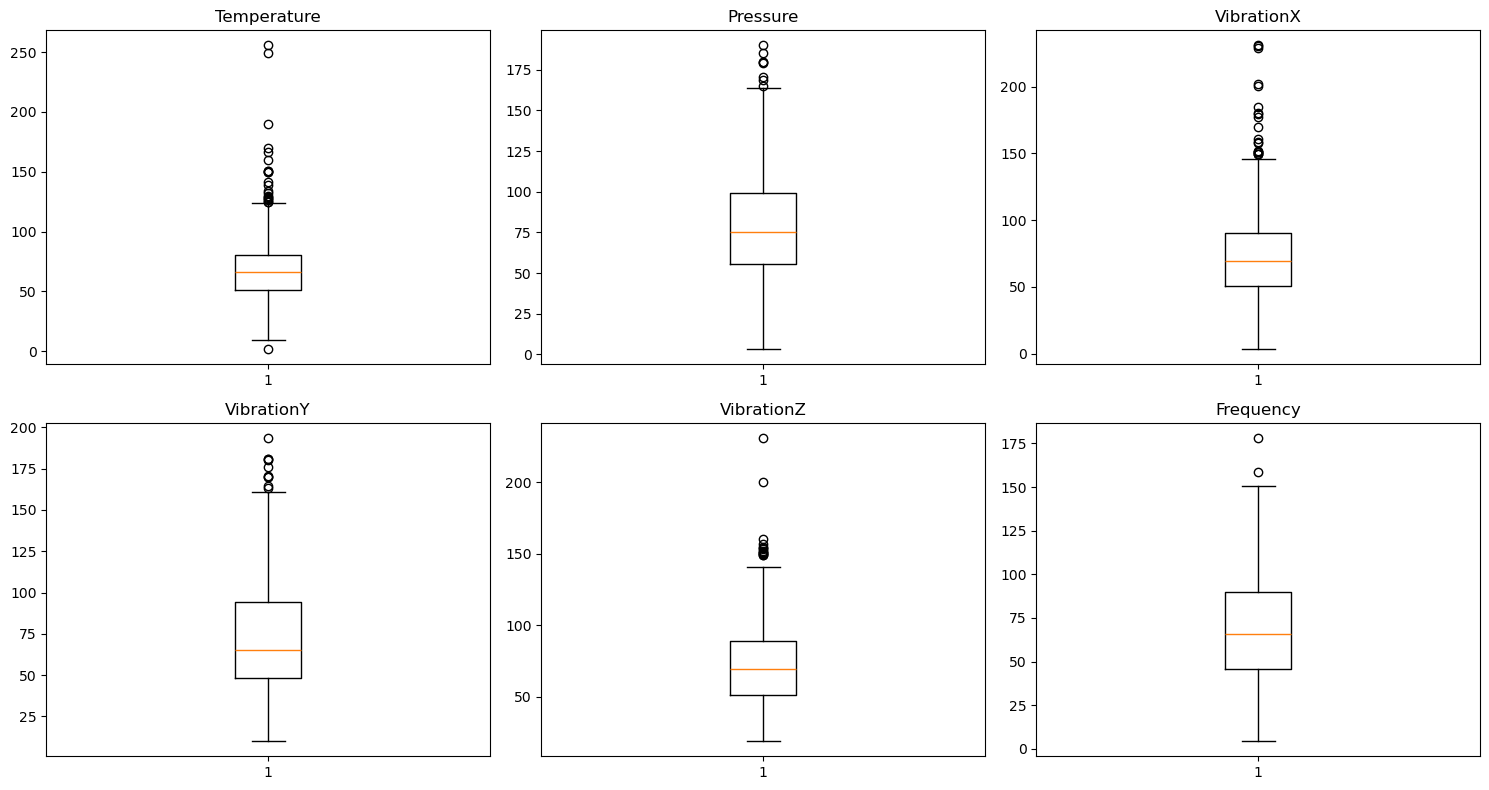

In [149]:
# Boxplots: visual outliers by the IQR rule

sensors = ["Temperature", "Pressure", "VibrationX", "VibrationY", "VibrationZ", "Frequency"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, sensors):
    ax.boxplot(df[col], vert=True)
    ax.set_title(col)
fig.tight_layout()
plt.show()

In [150]:
# Numeric outliers by the IQR rule, flagged by machine state

def iqr_outliers(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    mask = (series < lower) | (series > upper)
    return mask, lower, upper

for col in sensors:
    mask, lower, upper = iqr_outliers(df[col])
    out = df.loc[mask, [col, "Fail"]]
    n = len(out)
    n_fail = int(out["Fail"].sum())
    print(f"{col}: {n} outliers (bounds: {lower:.1f} / {upper:.1f}) "
          f"| {n_fail} in failure, {n - n_fail} in operation")

Temperature: 22 outliers (bounds: 6.8 / 124.8) | 5 in failure, 17 in operation
Pressure: 8 outliers (bounds: -10.2 / 165.0) | 5 in failure, 3 in operation
VibrationX: 20 outliers (bounds: -8.4 / 149.4) | 5 in failure, 15 in operation
VibrationY: 10 outliers (bounds: -19.8 / 162.4) | 6 in failure, 4 in operation
VibrationZ: 14 outliers (bounds: -6.4 / 146.0) | 8 in failure, 6 in operation
Frequency: 2 outliers (bounds: -20.5 / 156.5) | 1 in failure, 1 in operation


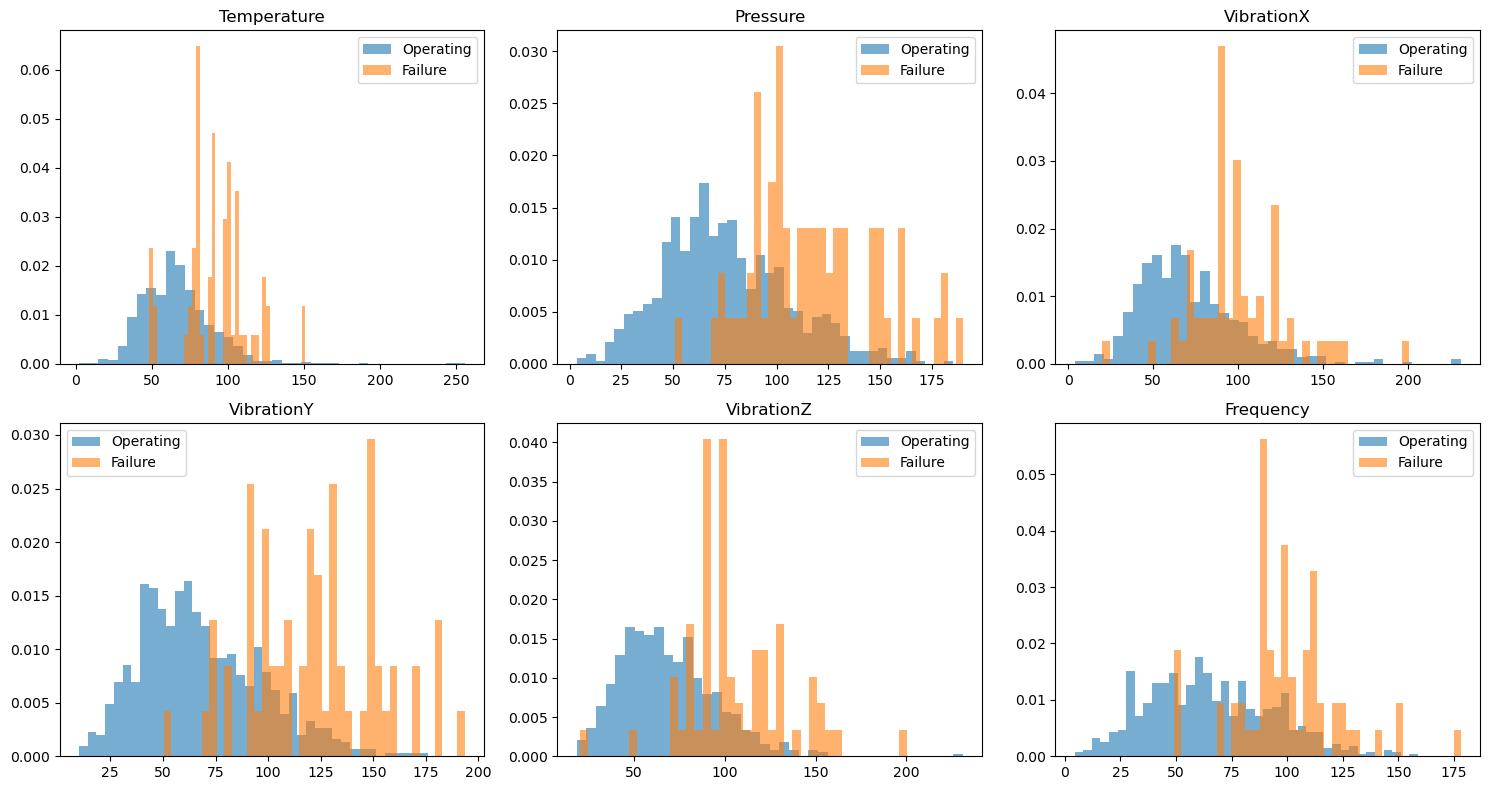

In [151]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, sensors):
    ax.hist(df.loc[~df["Fail"], col], bins=40, alpha=0.6, label="Operating", density=True)
    ax.hist(df.loc[df["Fail"], col], bins=40, alpha=0.6, label="Failure", density=True)
    ax.set_title(col)
    ax.legend()
fig.tight_layout()
plt.show()

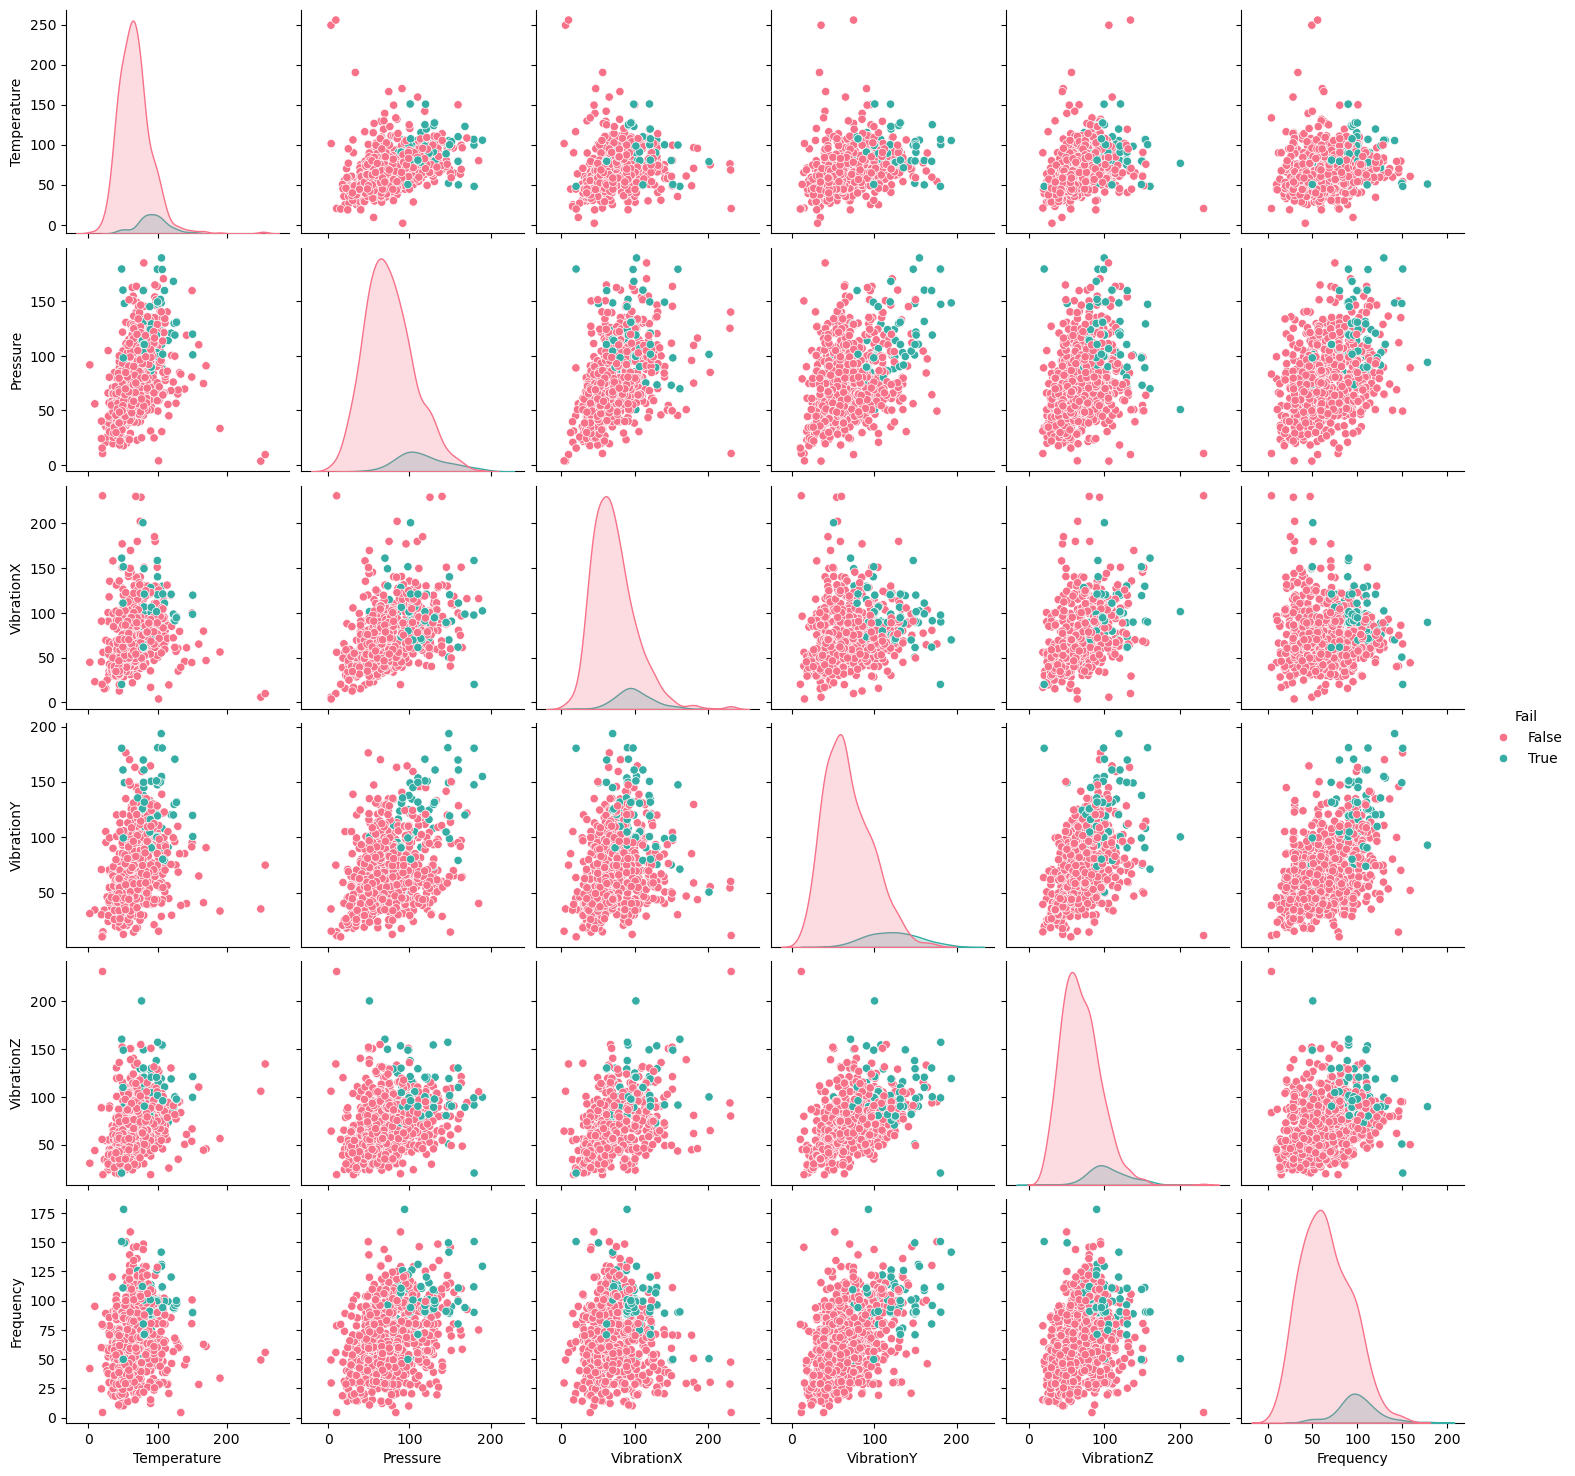

In [163]:
filtered_columns = ['Temperature', 'Pressure',
       'VibrationX', 'VibrationY', 'VibrationZ', 'Frequency', 'Fail']

sns.pairplot(df[filtered_columns], hue='Fail', palette='husl')

In [165]:
# Pearson (linear) and Spearman (monotonic) correlation among sensors

sensors = ["Temperature", "Pressure", "VibrationX", "VibrationY", "VibrationZ", "Frequency"]

pearson_corr = df[sensors].corr(method="pearson")
spearman_corr = df[sensors].corr(method="spearman")

print("Pearson:\n", pearson_corr.round(2).to_string())
print("\nSpearman:\n", spearman_corr.round(2).to_string())

Pearson:
              Temperature  Pressure  VibrationX  VibrationY  VibrationZ  Frequency
Temperature         1.00      0.42        0.24        0.36        0.38       0.17
Pressure            0.42      1.00        0.44        0.39        0.26       0.38
VibrationX          0.24      0.44        1.00        0.22        0.51       0.01
VibrationY          0.36      0.39        0.22        1.00        0.51       0.47
VibrationZ          0.38      0.26        0.51        0.51        1.00       0.26
Frequency           0.17      0.38        0.01        0.47        0.26       1.00

Spearman:
              Temperature  Pressure  VibrationX  VibrationY  VibrationZ  Frequency
Temperature         1.00      0.56        0.43        0.47        0.49       0.26
Pressure            0.56      1.00        0.51        0.36        0.32       0.37
VibrationX          0.43      0.51        1.00        0.31        0.58       0.09
VibrationY          0.47      0.36        0.31        1.00        0.57      

<div style="background:#f4f7f9; border-left:4px solid #1f7a8c; padding:12px 16px; margin:8px 0; font-family:sans-serif; line-height:1.6;">
  <strong style="color:#0b3d5c;">Initial Findings</strong>
  <ul style="margin:8px 0 0 0;">
    <li>There are 800 instances in the dataset.</li>
    <li>There are no missing values (every feature has 800 observations).</li>
    <li>Target variable (<code>Fail</code>) is binary.</li>
    <li><strong>Class imbalance:</strong> failure rows represent 8.25% of observations (91.75% vs. 8.25%). This is a per-row rate; because failures persist across consecutive cycles, the number of distinct failure events is much smaller. The effective imbalance for modeling will depend on how the prediction target is defined (see Target Definition).</li>
    <li>Outlier values cannot be directly associated with failures, since most outliers fall in the operating (non-failure) category. To find a reliable failure signal we likely need to look at the operating regimes (presets) and at the sensor values in the <em>n</em> cycles preceding each failure.</li>
    <li>Across all sensors, the failure-state distributions are shifted toward higher values relative to normal operation, but they overlap heavily with the operating distributions: most high values still occur during normal operation. A single-sensor threshold therefore cannot separate the classes, this overlap is what motivates a multivariate and/or temporal approach.</li>
    <li>Sensor-to-sensor correlations are low to moderate (max ~0.58), with no pair high enough to indicate redundancy, so no sensor is dropped on that basis. Spearman exceeds Pearson across most pairs, suggesting monotonic but non-linear relationships — which favors models able to capture non-linearity.</li>
  </ul>
</div>

## Task 1

1. Calculate how many times the equipment has failed.
During the FPSO’s operation, various factors can cause the machine to fail and prolong its failure
state. We ask you to explore the available data, identify, and calculate the number of times the
equipment has failed throughout its operation.

- Transform each fail True to 1 and False to 0.
- Compute diff to previous row to detect the transition of the state of the machine, this will result in 3 outputs:
  - 0 -> no changes in the state of the machine,
  - 1 -> failure starts,
  - -1 -> machine recovery
- failure_starts = True for output == 1, False otherwise (0 or -1)
- Sum all of the time a failure starts
- Handle the edge case where the machine starts in failure mode: failure_starts.iloc[0] = (fail.iloc[0] == 1) 

In [26]:
fail = df["Fail"].astype(int)
failure_starts = (fail.diff() == 1)
failure_starts.iloc[0] = (fail.iloc[0] == 1)  
n_events = int(failure_starts.sum())
n_events

10

### task 1 anwer

<div style="background:#f4f7f9; border-left:4px solid #1f7a8c; padding:12px 16px; margin:8px 0; font-family:sans-serif; line-height:1.6;">
  <ul style="margin:8px 0 0 0;">
    <li>Number of times the equipment has failed throughout its operation = <strong>10</strong></li>
  </ul>
</div>

## Task 2

2. Categorize equipment failures by setup configurations (Preset 1 and Preset 2). How do the variables Preset_1 and Preset_2 behave during operation? What insights can we derive from these variables?

### Analysis

In [39]:
df.Preset_1.value_counts(normalize=True)

Preset_1
2    0.35125
1    0.33000
3    0.31875
Name: proportion, dtype: float64

In [69]:
df.Preset_1.value_counts()

Preset_1
2    281
1    264
3    255
Name: count, dtype: int64

In [40]:
df.Preset_2.value_counts(normalize=True)

Preset_2
7    0.13625
6    0.12625
3    0.12625
2    0.12625
5    0.12500
8    0.12500
1    0.11875
4    0.11625
Name: proportion, dtype: float64

In [70]:
df.Preset_2.value_counts()

Preset_2
7    109
6    101
3    101
2    101
5    100
8    100
1     95
4     93
Name: count, dtype: int64

In [105]:
df.groupby("Preset_1")["Fail"].agg(["count", "sum", "mean"]).reset_index().sort_values(by=["mean"], ascending=False)

,Preset_1,count,sum,mean
0,1,264,27,0.102273
1,2,281,21,0.074733
2,3,255,18,0.070588


In [84]:
df.groupby("Preset_2")["Fail"].agg(["count", "sum", "mean"]).reset_index().sort_values(by=["mean"], ascending=False)

,Preset_2,count,sum,mean
4,5,100,12,0.120000
0,1,95,11,0.115789
1,2,101,9,0.089109
5,6,101,9,0.089109
6,7,109,9,0.082569
7,8,100,7,0.070000
2,3,101,6,0.059406
3,4,93,3,0.032258


In [107]:
df[failure_starts].groupby("Preset_1")["Fail"].agg(["count"]).reset_index().sort_values(by=["count"], ascending=False)

,Preset_1,count
0,1,5
2,3,4
1,2,1


In [108]:
df[failure_starts].groupby("Preset_2")["Fail"].agg(["count"]).reset_index().sort_values(by=["count"], ascending=False)

,Preset_2,count
0,1,3
3,6,3
1,2,2
2,3,1
4,8,1


In [109]:
pd.crosstab(df["Preset_1"], df["Preset_2"], values=df["Fail"], aggfunc="sum")

Preset_2,1,2,3,4,5,6,7,8
Preset_1,,,,,,,,
1,4,5,2,2,5,3,4,2
2,4,2,2,1,3,3,2,4
3,3,2,2,0,4,3,3,1


In [103]:
pd.crosstab(df[failure_starts]["Preset_1"], df[failure_starts]["Preset_2"], values=df["Fail"], aggfunc="sum")

Preset_2,1,2,3,6,8
Preset_1,,,,,
1,1.0,1.0,NaN,2.0,1.0
2,1.0,NaN,NaN,NaN,NaN
3,1.0,1.0,1.0,1.0,NaN


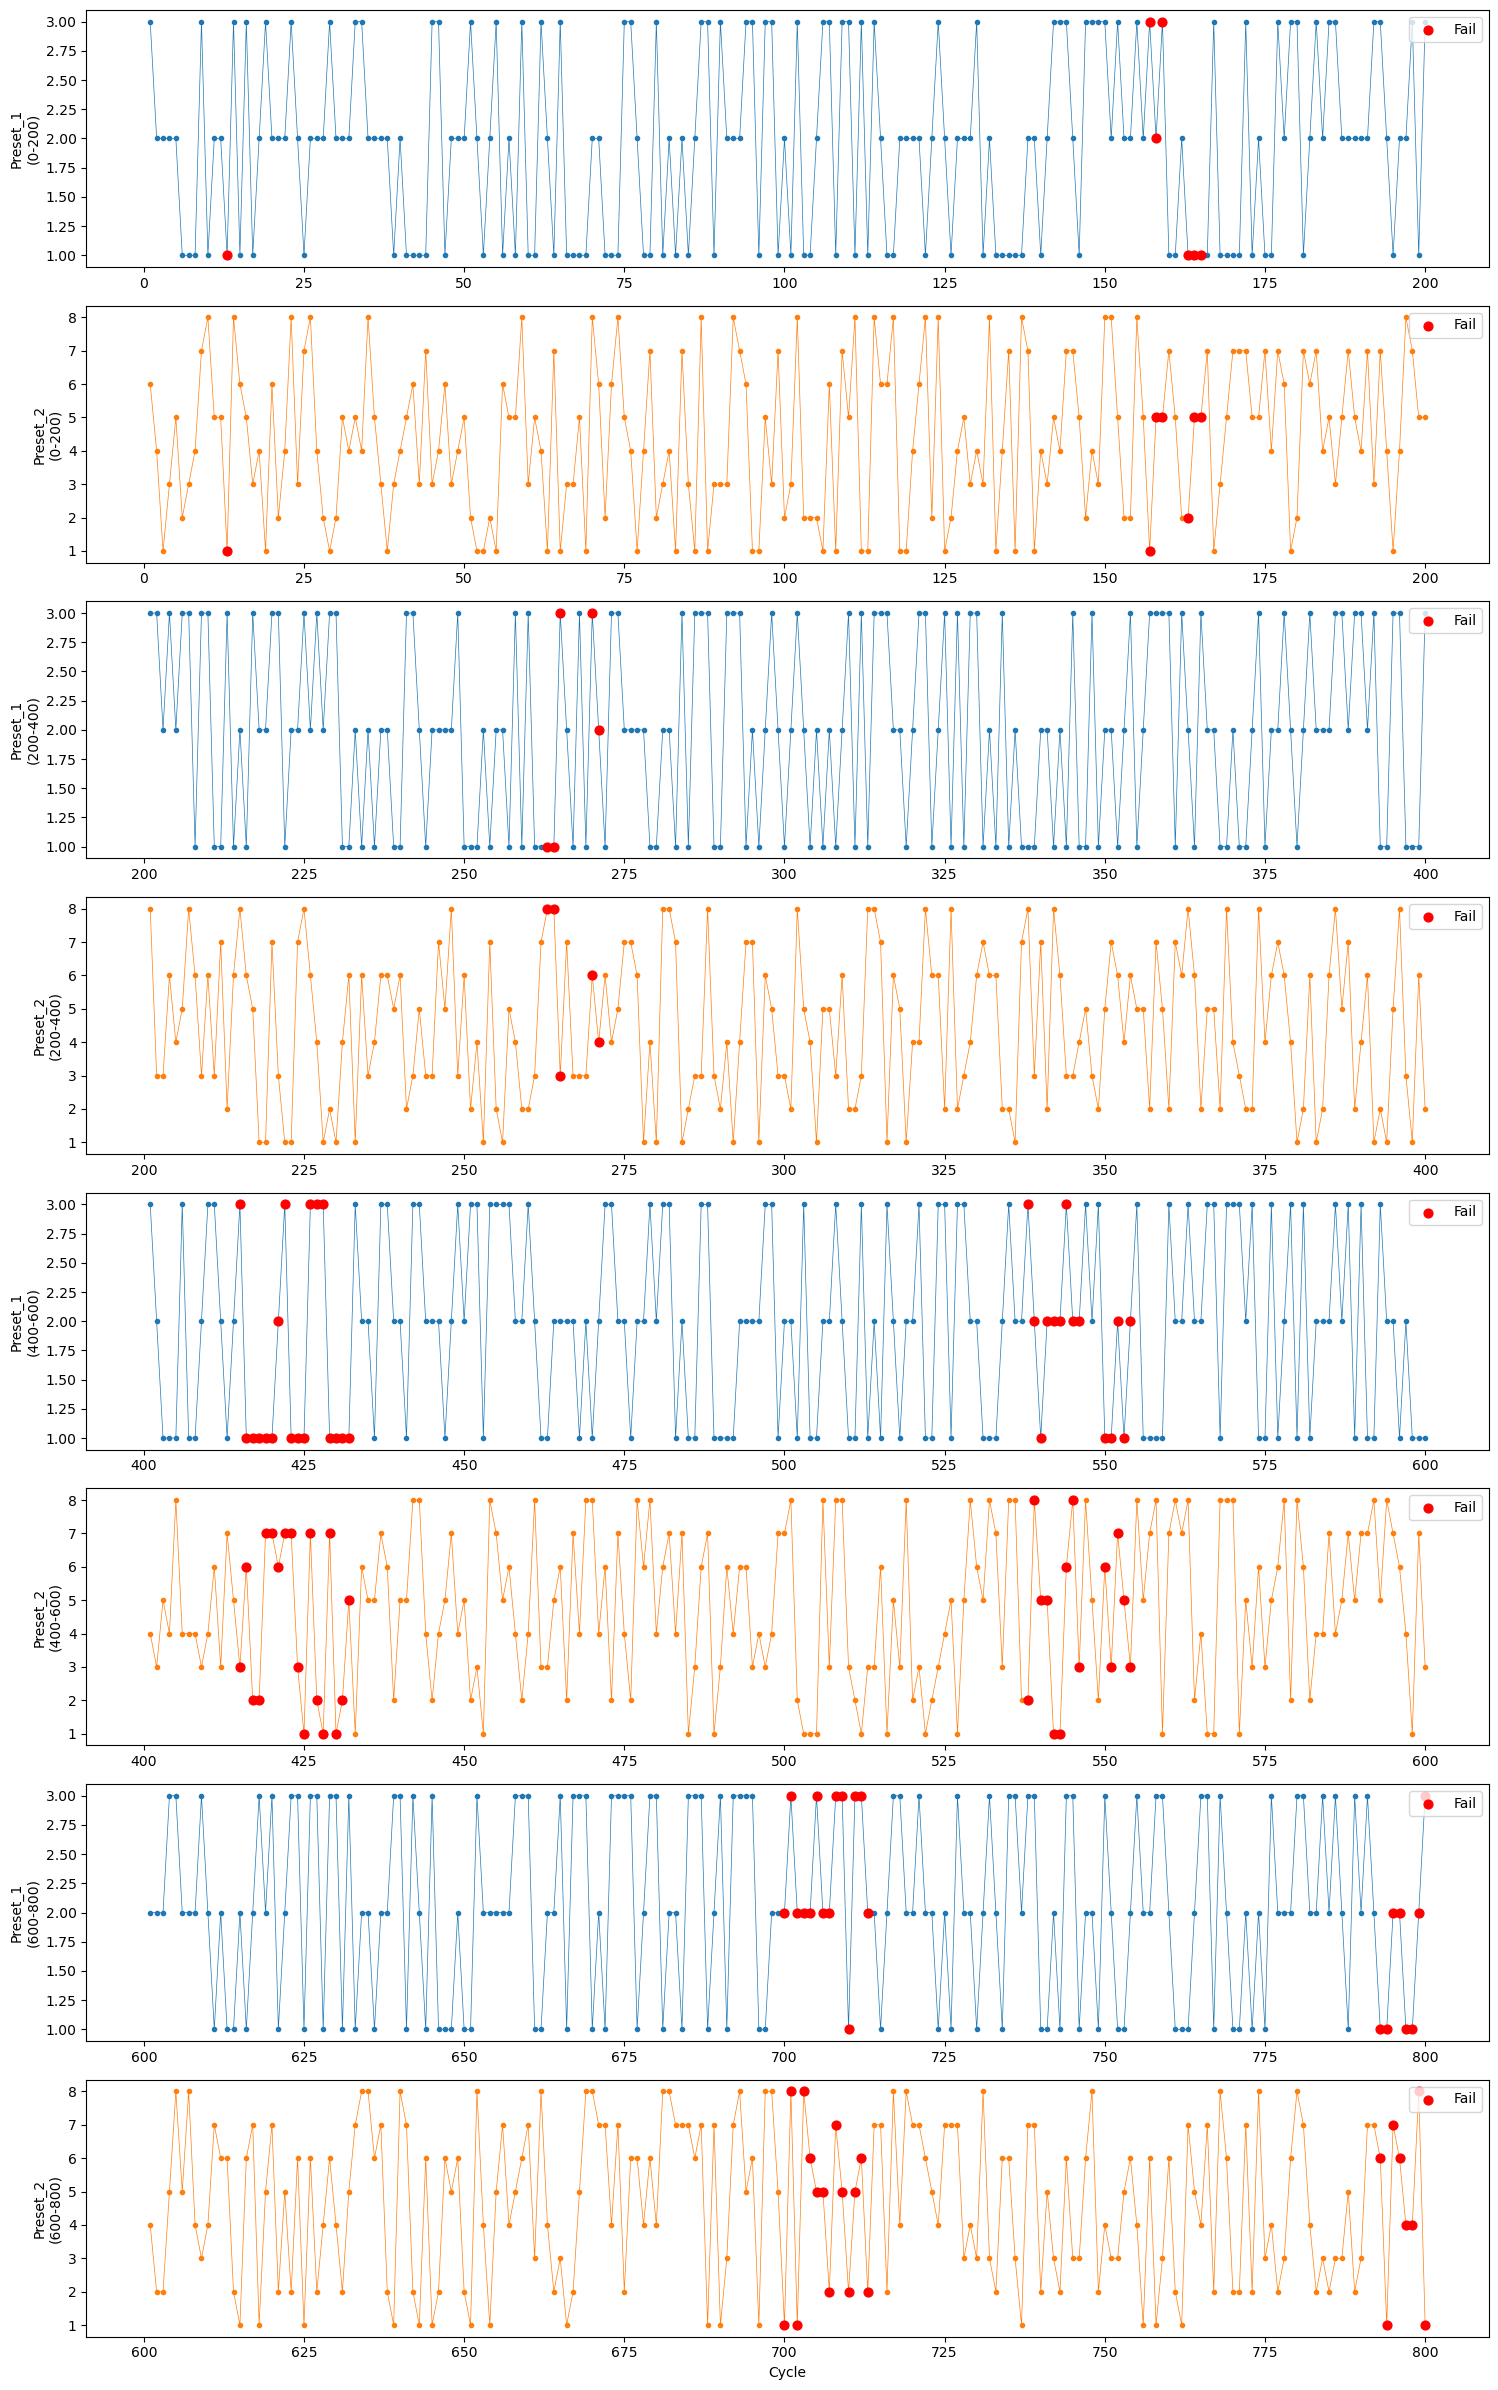

In [74]:
fail_mask = df["Fail"].values
chunk_size = 200
n_chunks = int(np.ceil(len(df) / chunk_size))

fig, axes = plt.subplots(n_chunks * 2, 1, figsize=(15, 3 * n_chunks * 2))
for i in range(n_chunks):
    lo, hi = i * chunk_size, (i + 1) * chunk_size
    seg = df.iloc[lo:hi]
    seg_fail = seg[seg["Fail"]]

    ax1 = axes[i * 2]
    ax1.plot(seg["Cycle"], seg["Preset_1"], marker=".", linewidth=0.5)
    ax1.scatter(seg_fail["Cycle"], seg_fail["Preset_1"], color="red", zorder=5, s=40, label="Fail")
    ax1.set_ylabel(f"Preset_1\n({lo}-{hi})")
    ax1.legend(loc="upper right")

    ax2 = axes[i * 2 + 1]
    ax2.plot(seg["Cycle"], seg["Preset_2"], marker=".", linewidth=0.5, color="tab:orange")
    ax2.scatter(seg_fail["Cycle"], seg_fail["Preset_2"], color="red", zorder=5, s=40, label="Fail")
    ax2.set_ylabel(f"Preset_2\n({lo}-{hi})")
    ax2.legend(loc="upper right")

axes[-1].set_xlabel("Cycle")
fig.tight_layout()
plt.show()

### Task 2 answer

<div style="background:#f4f7f9; border-left:4px solid #1f7a8c; padding:12px 16px; margin:8px 0; font-family:sans-serif; line-height:1.6;">
  <ul style="margin:8px 0 0 0;">
    <li><strong>Sawtooth behavior.</strong> <code>Preset_1</code> and <code>Preset_2</code> change every cycle, showing no plateau or prolonged regime, they act as an instantaneous operating condition, not as extended operating phases. No regime shift is observed prior to failure.</li>
    <li><strong>Failures categorized by configuration (two complementary lenses).</strong> Per-row (marginal tables): the share of time spent in failure under each preset level. Per-event (<code>df[failure_starts]</code>): the configuration active at the moment each failure was triggered. Both are reported because they answer different questions; they converge on the same conclusion.</li>
    <li><strong>Per-event view is too sparse for conclusions.</strong> The 10 failure events are scattered across 9 of the 24 possible <code>Preset_1</code>&times;<code>Preset_2</code> combinations, with at most 2 per cell. With 10 events over 24 cells, a count of 2 in a single cell is expected by chance and does not indicate a higher-risk configuration.</li>
    <li><strong><code>Preset_1</code> marginal:</strong> level 1 shows a slightly higher failure rate (~10% vs. ~7%), but the difference is weak and likely within sampling noise.</li>
    <li><strong><code>Preset_2</code> marginal:</strong> failure rates range from ~3% to ~12% across its 8 levels, but this compares post-hoc extremes over many levels with ~100 samples each; the gap is roughly 2 standard errors and is compatible with sampling noise. No single level is reliably more failure-prone.</li>
  </ul>
  <p style="margin:8px 0 0 0;">Taken together, the failure signal is <strong>not in the instantaneous operating configuration</strong>, neither in individual presets nor in their combination. This motivates the temporal analysis that follows: the signal is likely in the <em>dynamics</em>, i.e. how sensor values evolve in the cycles preceding a failure.</p>
</div>

## Task 3

3. Categorize equipment failures by their nature/root cause according to parameter
readings (temperature, pressure, and others). </br>
Analyze patterns in these readings that could indicate specific failure types. How do these
patterns differ across operational regimes? Provide insights based on your findings.

### Analysis

In [215]:
sensors = ["Temperature", "Pressure", "VibrationX", "VibrationY", "VibrationZ", "Frequency"]

# Reference statistics computed on NORMAL operation only, to avoid letting
# failure values contaminate the definition of "normal".
normal = df[~df["Fail"]]

# Global z-score: how far each value is from the overall normal baseline
for s in sensors:
    mu, sigma = normal[s].mean(), normal[s].std()
    df[f"{s}_z"] = (df[s] - mu) / sigma

# Per-regime z-score: "normal" defined within each Preset_1 level
# Uses transform so each row is standardized against its own regime's normal stats.
normal_stats = normal.groupby("Preset_1")[sensors].agg(["mean", "std"])

for s in sensors:
    # map each row's regime to that regime's normal mean/std
    mu = df["Preset_1"].map(normal_stats[(s, "mean")])
    sigma = df["Preset_1"].map(normal_stats[(s, "std")])
    df[f"{s}_z_regime"] = (df[s] - mu) / sigma

In [216]:
# Sanity-check the per-regime z-score denominators: each sensor's normal std
# should be similar across Preset_1 levels. A collapsed/near-zero std in one
# regime would inflate that regime's z-scores and create false extremes.

sigmas = normal.groupby("Preset_1")[sensors].std()
sigmas.round(2).reset_index()

,Preset_1,Temperature,Pressure,VibrationX,VibrationY,VibrationZ,Frequency
0,1,27.37,30.67,30.24,30.83,27.30,26.31
1,2,23.61,28.67,29.00,29.10,25.69,28.53
2,3,23.50,32.49,32.09,26.98,23.90,28.92


In [169]:
# Quantify how close the global and per-regime z-scores are, per sensor

for s in sensors:
    diff = (df[f"{s}_z"] - df[f"{s}_z_regime"]).abs()
    print(f"{s}: mean abs diff = {diff.mean():.3f}, max abs diff = {diff.max():.3f}")

Temperature: mean abs diff = 0.054, max abs diff = 0.699
Pressure: mean abs diff = 0.049, max abs diff = 0.238
VibrationX: mean abs diff = 0.054, max abs diff = 0.297
VibrationY: mean abs diff = 0.065, max abs diff = 0.362
VibrationZ: mean abs diff = 0.071, max abs diff = 0.369
Frequency: mean abs diff = 0.048, max abs diff = 0.235


In [213]:
# Confirm the regime conclusion holds for Preset_2 as well (8 levels, ~90 normal samples each)
normal_stats_p2 = normal.groupby("Preset_2")[sensors].agg(["mean", "std"])

for s in sensors:
    mu = df["Preset_2"].map(normal_stats_p2[(s, "mean")])
    sigma = df["Preset_2"].map(normal_stats_p2[(s, "std")])
    df[f"{s}_z_regime_p2"] = (df[s] - mu) / sigma

# Quantify closeness to the global z-score
print("Global vs per-Preset_2 z-score difference:")
for s in sensors:
    diff = (df[f"{s}_z"] - df[f"{s}_z_regime_p2"]).abs()
    print(f"{s}: mean abs diff = {diff.mean():.3f}, max abs diff = {diff.max():.3f}")

Global vs per-Preset_2 z-score difference:
Temperature: mean abs diff = 0.163, max abs diff = 1.621
Pressure: mean abs diff = 0.104, max abs diff = 0.619
VibrationX: mean abs diff = 0.067, max abs diff = 0.385
VibrationY: mean abs diff = 0.113, max abs diff = 0.570
VibrationZ: mean abs diff = 0.099, max abs diff = 0.525
Frequency: mean abs diff = 0.105, max abs diff = 0.363


<div style="background:#f4f7f9; border-left:4px solid #1f7a8c; padding:12px 16px; margin:8px 0; font-family:sans-serif; line-height:1.6;">
  <strong style="color:#0b3d5c;">Operating regime does not modulate sensor behavior</strong>
  <p style="margin:8px 0 0 0;">Standardizing each sensor against the global normal baseline and against each regime's own normal baseline produces nearly identical z-scores for <code>Preset_1</code>: the mean absolute difference per sensor is only ~0.05–0.07 SD (max ~0.7 SD in isolated points), with no collapsed or inflated per-regime denominators. This indicates the normal behavior of the sensors does not depend on the <code>Preset_1</code> regime.</p>
  <p style="margin:8px 0 0 0;">For <code>Preset_2</code> the differences are somewhat larger (mean abs diff ~0.07–0.16 SD, highest for Temperature). However, <code>Preset_2</code> has 8 levels with only ~90 normal samples each, versus ~240 per level for <code>Preset_1</code>'s 3 levels, so its per-level mean/std estimates are less stable. These larger differences are plausibly estimation noise from the smaller per-level sample rather than genuine modulation; the data cannot distinguish the two at this sample size. We therefore treat the <code>Preset_1</code> result as robust and the <code>Preset_2</code> result as inconclusive.</p>
  <p style="margin:8px 0 0 0;">Either way, the effect is modest, so we analyze failure signatures globally rather than slicing the 10 events across regimes (which would be too sparse to support conclusions). We proceed with the global z-score.</p>
</div>

In [170]:
regime_cols = [f"{s}_z_regime" for s in sensors]
df = df.drop(columns=regime_cols, errors="ignore")

In [214]:
regime_cols = [f"{s}_z_regime_p2" for s in sensors]
df = df.drop(columns=regime_cols, errors="ignore")

In [206]:
# cycles before onset (to spot precursors) and a few after (to see the episode)

z_cols = [f"{s}_z" for s in sensors]

THRESHOLD = 2.0

# Fraction of NORMAL-operation points exceeding z=2, per sensor
# (justifies the threshold: crossing 2 should be rare under normal behavior)
normal_rows = df[~df["Fail"]]
fail_rows = df[df["Fail"]]

print(f"Fraction of points with z > {THRESHOLD} (per sensor):\n")
print(f"{'Sensor':<14}{'Normal':>10}{'Failure':>10}")
for s, zc in zip(sensors, z_cols):
    frac_normal = (normal_rows[zc] > THRESHOLD).mean()
    frac_fail = (fail_rows[zc] > THRESHOLD).mean()
    print(f"{s:<14}{frac_normal:>10.3%}{frac_fail:>10.3%}")

# Overall, pooling all sensors
all_normal = (normal_rows[z_cols] > THRESHOLD).values.mean()
all_fail = (fail_rows[z_cols] > THRESHOLD).values.mean()
print(f"\nOverall: {all_normal:.3%} of normal sensor-readings vs {all_fail:.3%} of failure sensor-readings exceed z={THRESHOLD}")

Fraction of points with z > 2.0 (per sensor):

Sensor            Normal   Failure
Temperature       2.589%   12.121%
Pressure          3.406%   22.727%
VibrationX        3.406%    9.091%
VibrationY        3.815%   42.424%
VibrationZ        3.270%   28.788%
Frequency         2.725%   13.636%

Overall: 3.202% of normal sensor-readings vs 21.465% of failure sensor-readings exceed z=2.0


<div style="background:#f4f7f9; border-left:4px solid #1f7a8c; padding:12px 16px; margin:8px 0; font-family:sans-serif; line-height:1.6;">
  <p style="margin:8px 0 0 0;">The z=2 threshold is anchored both theoretically (≈2 SD from normal behavior) and empirically: only 3.2% of normal-operation sensor readings exceed it, versus 21.5% during failure (≈7× higher), confirming it discriminates between regimes rather than flagging routine fluctuation.</strong>.</p>
</div>

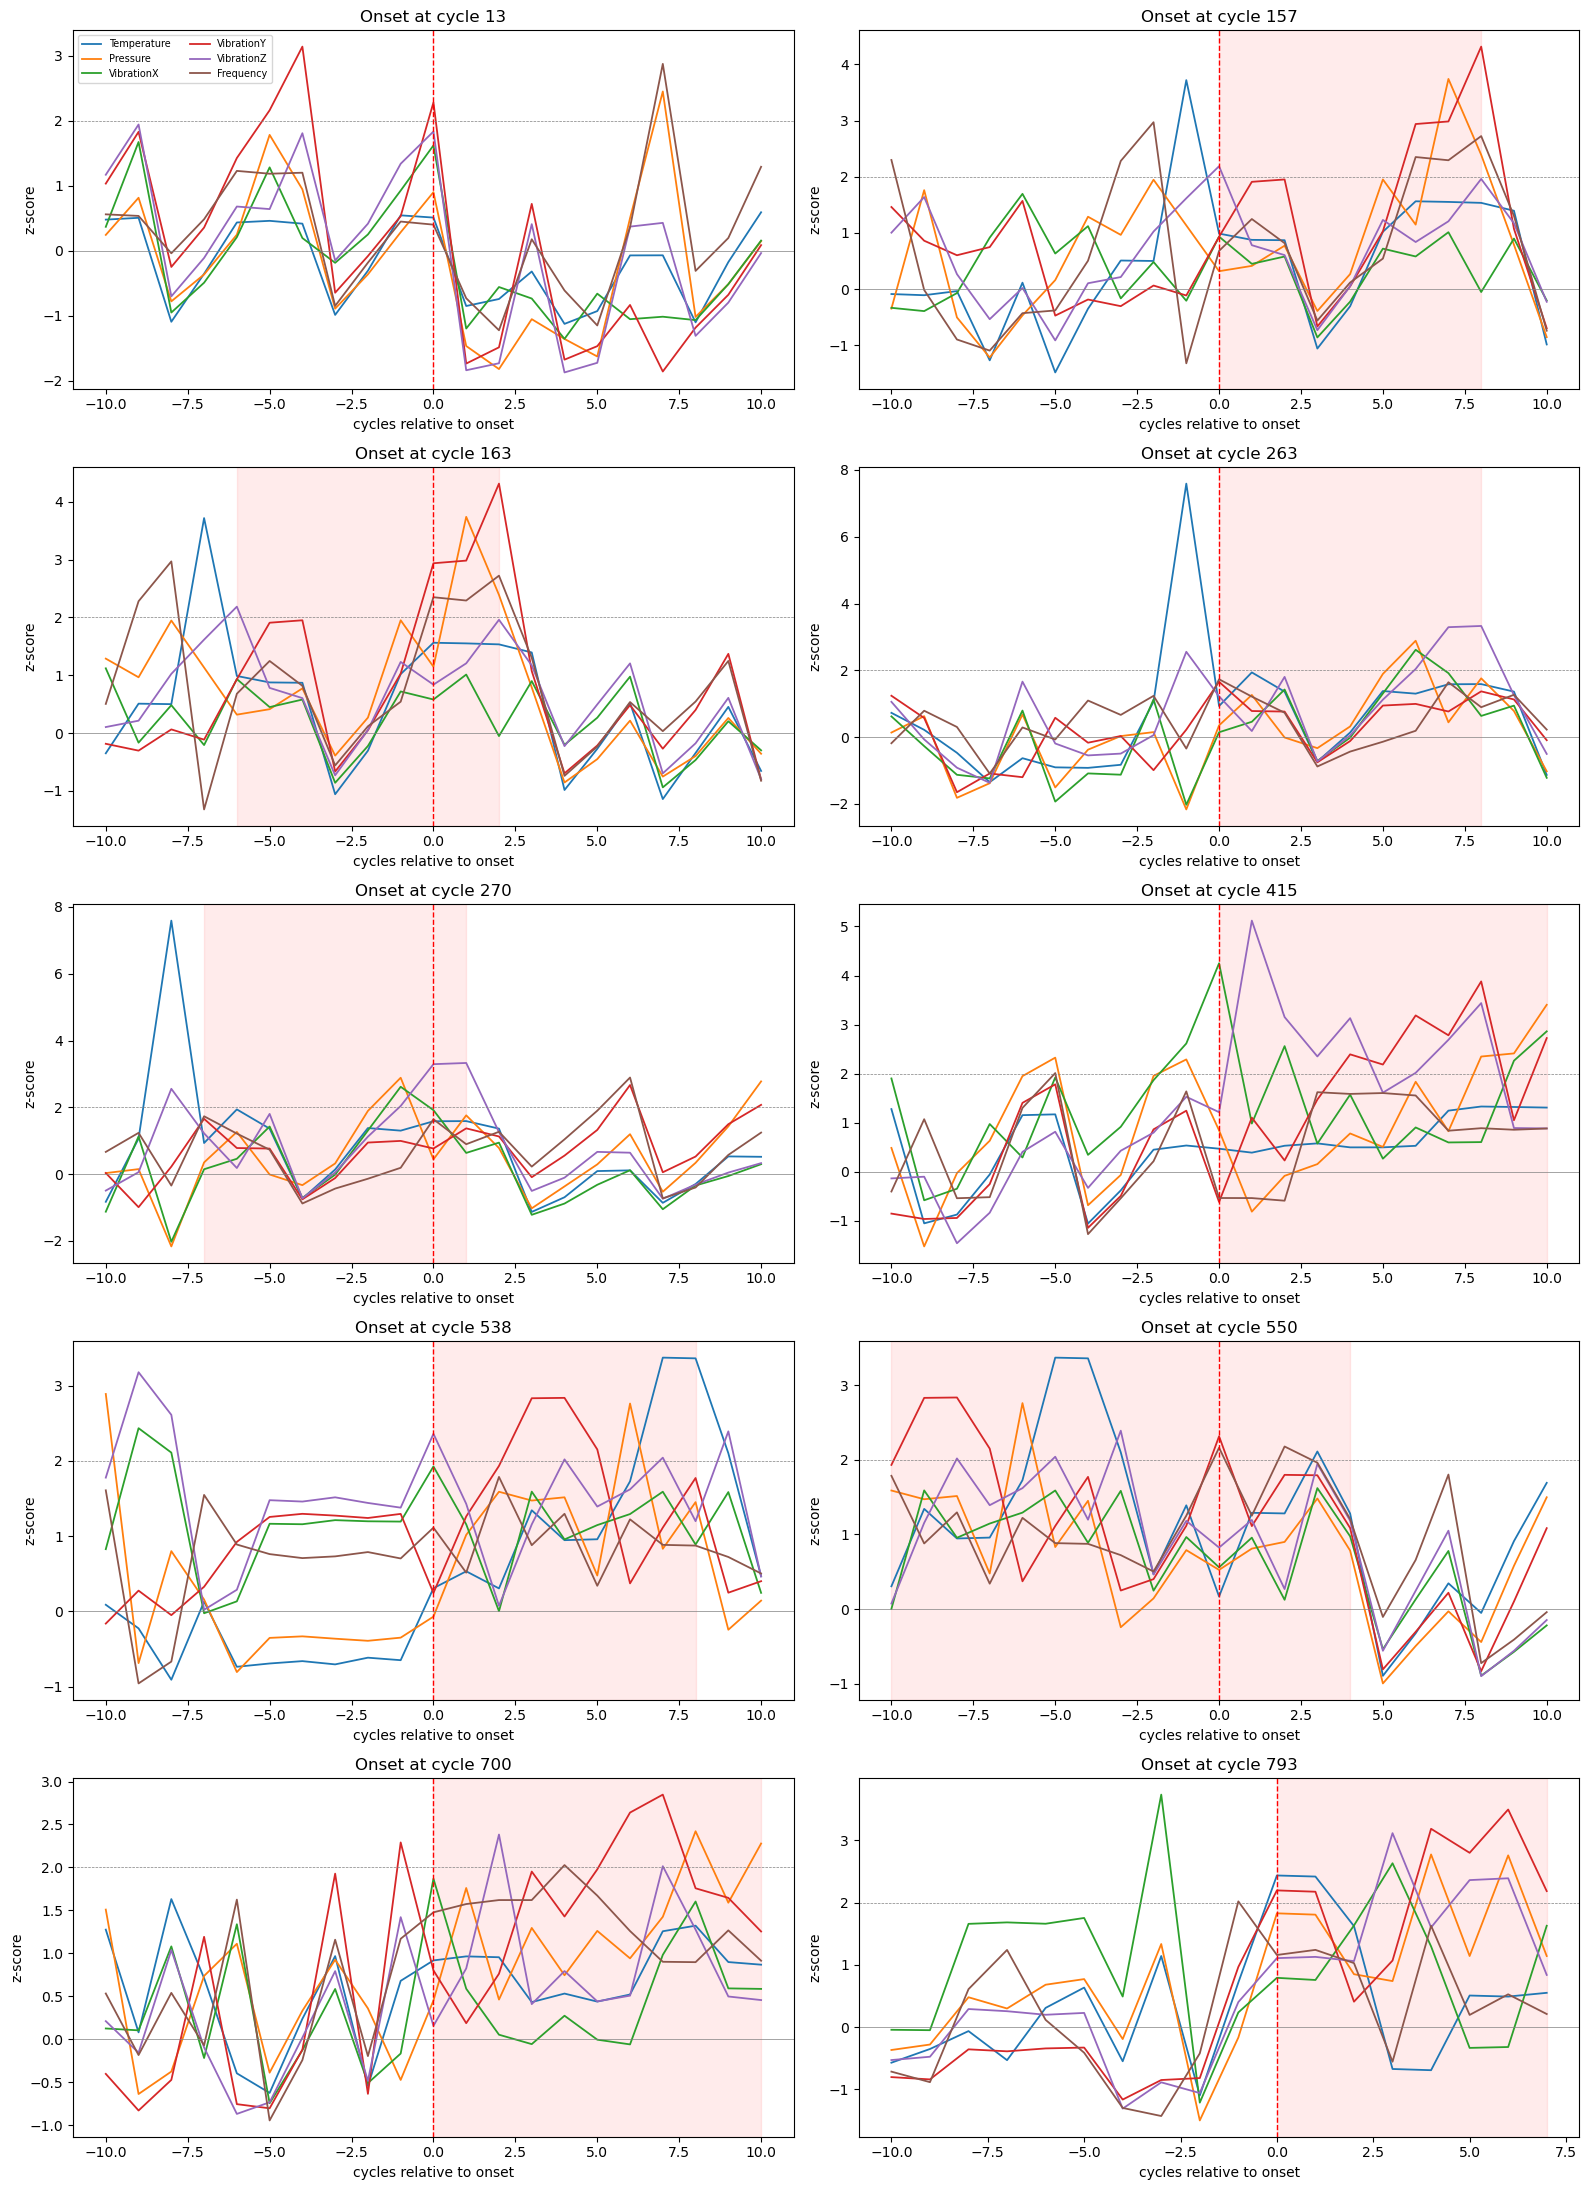

In [211]:

z_cols = [f"{s}_z" for s in sensors]
onset_cycles = df.loc[failure_starts, "Cycle"].tolist()

BEFORE, AFTER = 10, 10 

fig, axes = plt.subplots(5, 2, figsize=(16, 22))
for ax, onset in zip(axes.flat, onset_cycles):
    lo, hi = onset - BEFORE, onset + AFTER
    window = df[(df["Cycle"] >= lo) & (df["Cycle"] <= hi)]
    rel_t = window["Cycle"] - onset  # 0 = onset, negative = before

    for s, zc in zip(sensors, z_cols):
        ax.plot(rel_t, window[zc], linewidth=1.3, label=s)

    # shade the failure region (relative time)
    fail_in_window = window[window["Fail"]]
    if not fail_in_window.empty:
        ax.axvspan((fail_in_window["Cycle"] - onset).min(),
                   (fail_in_window["Cycle"] - onset).max(),
                   color="red", alpha=0.08)
    ax.axvline(0, color="red", linestyle="--", linewidth=1)
    ax.axhline(2, color="gray", linestyle="--", linewidth=0.5) 
    ax.axhline(0, color="gray", linewidth=0.5)  # z=0 reference (normal)
    ax.set_title(f"Onset at cycle {onset}")
    ax.set_xlabel("cycles relative to onset")
    ax.set_ylabel("z-score")

axes.flat[0].legend(loc="upper left", fontsize=7, ncol=2)
fig.tight_layout()
plt.show()

In [189]:
z_cols = [f"{s}_z" for s in sensors]
onset_cycles = df.loc[failure_starts, "Cycle"].tolist()

BEFORE = 5
THRESHOLD = 2.0

rows = []
for onset in onset_cycles:
    pre = df[(df["Cycle"] >= onset - BEFORE) & (df["Cycle"] < onset)]  # strictly before onset
    # sensors whose peak z exceeds the threshold in the pre-failure window
    flagged = [s for s, zc in zip(sensors, z_cols) if pre[zc].max() > THRESHOLD]
    rows.append({"onset": onset, "signature": ", ".join(flagged) if flagged else "(none)", "n_sensors": len(flagged)})

signatures = pd.DataFrame(rows).set_index("onset")
print(signatures.to_string())

                              signature  n_sensors
onset                                             
13                           VibrationY          1
157              Temperature, Frequency          2
163                              (none)          0
263             Temperature, VibrationZ          2
270    Pressure, VibrationX, VibrationZ          3
415     Pressure, VibrationX, Frequency          3
538                              (none)          0
550             Temperature, VibrationZ          2
700                          VibrationY          1
793               VibrationX, Frequency          2


In [195]:
z_cols = [f"{s}_z" for s in sensors]
onset_cycles = df.loc[failure_starts, "Cycle"].tolist()

BEFORE = 3
THRESHOLD = 2.0

rows = []
for onset in onset_cycles:
    pre = df[(df["Cycle"] >= onset - BEFORE) & (df["Cycle"] < onset)]  # strictly before onset
    # sensors whose peak z exceeds the threshold in the pre-failure window
    flagged = [s for s, zc in zip(sensors, z_cols) if pre[zc].max() > THRESHOLD]
    rows.append({"onset": onset, "signature": ", ".join(flagged) if flagged else "(none)", "n_sensors": len(flagged)})

signatures = pd.DataFrame(rows).set_index("onset")
print(signatures.to_string())

                              signature  n_sensors
onset                                             
13                               (none)          0
157              Temperature, Frequency          2
163                              (none)          0
263             Temperature, VibrationZ          2
270    Pressure, VibrationX, VibrationZ          3
415                Pressure, VibrationX          2
538                              (none)          0
550             Temperature, VibrationZ          2
700                          VibrationY          1
793               VibrationX, Frequency          2


<div style="background:#f4f7f9; border-left:4px solid #1f7a8c; padding:12px 16px; margin:8px 0; font-family:sans-serif; line-height:1.6;">
  <strong style="color:#0b3d5c;">Pre-failure window choice (5 cycles)</strong>
  <p style="margin:8px 0 0 0;">The pre-failure window is set to 5 cycles. Comparing 3- vs 5-cycle windows showed that some episodes (e.g. onset 13) exhibit precursor signals only 4–5 cycles before failure, which a 3-cycle window misses entirely. Capturing these justifies the longer window.</p>
  <p style="margin:8px 0 0 0;">The trade-off: for the three most closely-spaced episodes (minimum inter-episode gap = 4 cycles), the 5-cycle window may include 1–2 cycles of the preceding episode, a limitation we note explicitly, inherent to the event proximity in this dataset.</p>
</div>

In [212]:
# Signature AT onset: sensors exceeding z=2 at the failure-start cycle

z_cols = [f"{s}_z" for s in sensors]
THRESHOLD = 2.0

onset_df = df.loc[failure_starts, ["Cycle"] + z_cols].reset_index(drop=True)
rows = []
for _, r in onset_df.iterrows():
    flagged = [s for s, zc in zip(sensors, z_cols) if r[zc] > THRESHOLD]
    rows.append({"onset": int(r["Cycle"]),
                 "onset_signature": ", ".join(flagged) if flagged else "(none)"})

print(pd.DataFrame(rows).set_index("onset").to_string())

               onset_signature
onset                         
13                  VibrationY
157                 VibrationZ
163      VibrationY, Frequency
263                     (none)
270                 VibrationZ
415                 VibrationX
538                 VibrationZ
550      VibrationY, Frequency
700                     (none)
793    Temperature, VibrationY


### Answer Task 3

<div style="background:#f4f7f9; border-left:4px solid #1f7a8c; padding:12px 16px; margin:8px 0; font-family:sans-serif; line-height:1.6;">
  <strong style="color:#0b3d5c;">Task 3 — Failure categorization by sensor signature</strong>
  <ul style="margin:8px 0 0 0;">
    <li><strong>Regime does not materially change patterns.</strong> Sensor behavior standardized per operating regime is nearly identical to the global baseline (robust for <code>Preset_1</code>; inconclusive but modest for <code>Preset_2</code> due to small per-level samples). So failure signatures are analyzed globally rather than sliced by regime.</li>
    <li><strong>Failures are heterogeneous.</strong> Using a z &gt; 2 anomaly threshold (z &gt; 2 occurs in only 3.2% of normal readings vs 21.5% during failure, ~7×), the pre-failure signature varies across episodes: some are thermal (Temperature/Frequency), others vibrational on different axes (VibrationX, Y, or Z), and others mixed. There is no single shared failure signature.</li>
    <li><strong>Candidate failure types</strong> (tentative): <b>thermal</b> (onsets 157, 263, 550), <b>vibrational</b> (13, 270, 415, 700, 793), and <b>no-clear-precursor / near-sudden</b> (163, 538). These are exploratory groupings, not validated types.</li>
    <li><strong>Precursor ≠ onset signature.</strong> The sensors anomalous in the cycles <em>before</em> failure generally differ from those anomalous <em>at</em> onset (e.g. onset 263: Temperature precursor, no clear onset signal). This is partly a measurement artifact (precursor = peak over 5 cycles vs onset = single cycle), but it also indicates that pre-failure dynamics carry information the instantaneous value does not, supporting the use of windowed/temporal features in the model (Task 4).</li>
  </ul>
  <p style="margin:8px 0 0 0;"><strong>Caveat:</strong> with only 10 failure events, any typification rests on 2–3 episodes per group and cannot be statistically validated. Inter-episode contamination (minimum gap = 4 cycles) also adds noise to precursor measurement. The typology should be read as an exploratory hypothesis for investigation with more data, not a confirmed taxonomy.</p>
</div>

## Task 4

### Data Prep

In [217]:
def create_target(df: pd.DataFrame, tau: int, fail_col: str = "Fail") -> pd.Series:
    """Build a predictive-maintenance target: will the machine fail within the next 'tau' cycles?

    For each row at cycle t, the target is 1 if a failure occurs in the window
    (t, t + tau], i.e. in any of the next 'tau' cycles, and 0 otherwise.

    Rows that are already in a failure state are excluded from being positive
    targets (we predict the onset of failure, not its continuation): the caller
    should decide whether to drop in-failure rows before training.

    Args:
        df: DataFrame sorted by cycle, containing a boolean failure column.
        tau: Lookahead horizon in cycles (must be >= 1).
        fail_col: Name of the boolean failure column.

    Returns:
        Int Series (0/1) aligned to df.index: 1 if failure occurs within the
        next 'tau' cycles, else 0.
    """
    if tau < 1:
        raise ValueError(f"tau must be >= 1, got {tau}")

    fail = df[fail_col].astype(int).to_numpy()
    n = len(fail)
    target = np.zeros(n, dtype=int)

    for i in range(n):
        # look at the next tau cycles: positions i+1 .. i+tau
        window = fail[i + 1 : i + 1 + tau]
        if window.sum() > 0:
            target[i] = 1

    return pd.Series(target, index=df.index, name=f"will_fail_within_{tau}")

In [221]:
def add_window_features(
    df: pd.DataFrame,
    sensors: list[str],
    windows: tuple[int, ...] = (3, 5),
    stats: tuple[str, ...] = ("mean", "std"),
) -> pd.DataFrame:
    """Add backward-looking rolling-window features for each sensor.

    For each sensor and window size, computes rolling statistics over the
    current and preceding 'w - 1' cycles (trailing window, never centered),
    so no future information leaks into a row's features.

    Args:
        df: DataFrame sorted by cycle.
        sensors: Sensor column names to compute features for.
        windows: Rolling window sizes in cycles.
        stats: Statistics to compute ('mean', 'std').

    Returns:
        A copy of df with added feature columns named '{sensor}_{stat}_{w}'.
    """
    out = df.copy()
    for sensor in sensors:
        for w in windows:
            roll = out[sensor].rolling(window=w, min_periods=1)
            for stat in stats:
                out[f"{sensor}_{stat}_{w}"] = getattr(roll, stat)()
    return out

In [218]:
def temporal_split(df: pd.DataFrame, cycle_col: str = "Cycle", test_ratio: float = 0.2) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Split chronologically: earliest (1 - test_ratio) cycles for train, latest for test.

    No shuffling — train always precedes test in time, preventing temporal leakage.

    Args:
        df: DataFrame sorted by cycle.
        cycle_col: Name of the cycle column.
        test_ratio: Fraction of the time span held out as the most recent test set.

    Returns:
        (train_df, test_df) split at the temporal cutoff.
    """
    cutoff = df[cycle_col].quantile(1 - test_ratio)
    train = df[df[cycle_col] <= cutoff].copy()
    test = df[df[cycle_col] > cutoff].copy()
    return train, test

In [219]:
from sklearn.preprocessing import StandardScaler

def prepare_data(
    df: pd.DataFrame,
    sensors: list[str],
    tau: int,
    windows: tuple[int, ...] = (3, 5),
    test_ratio: float = 0.2,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series, list[str]]:
    """End-to-end preprocessing for the predictive-maintenance task.

    Pipeline:
        1. Build the lookahead target on the full series.
        2. Add backward-looking window features on the full series (needs temporal continuity).
        3. Drop in-failure rows (we predict onset, not continuation).
        4. Temporal train/test split (no shuffle).
        5. Fit the scaler on train only, transform both.

    Args:
        df: Raw DataFrame sorted by cycle.
        sensors: Sensor column names.
        tau: Lookahead horizon in cycles.
        windows: Rolling window sizes.
        test_ratio: Most-recent fraction held out for testing.

    Returns:
        (X_train, X_test, y_train, y_test, feature_cols), scaled and ready to fit a model.
    """
    work = df.sort_values("Cycle").reset_index(drop=True).copy()

    # (1) target on the full series
    work["target"] = create_target(work, tau=tau)

    # (2) window features on the full series (backward-looking, no leakage)
    work = add_window_features(work, sensors=sensors, windows=windows)

    # (3) drop in-failure rows: predict the onset, not the failure state itself
    work = work[~work["Fail"]].copy()

    # feature columns: raw sensors + window features (exclude target, Fail, Cycle, presets)
    window_cols = [f"{s}_{stat}_{w}" for s in sensors for w in windows for stat in ("mean", "std")]
    feature_cols = sensors + window_cols

    # (4) temporal split
    train, test = temporal_split(work, test_ratio=test_ratio)

    # (5) fit scaler on train only, transform both
    scaler = StandardScaler()
    X_train = pd.DataFrame(
        scaler.fit_transform(train[feature_cols]),
        columns=feature_cols, index=train.index,
    )
    X_test = pd.DataFrame(
        scaler.transform(test[feature_cols]),
        columns=feature_cols, index=test.index,
    )
    y_train = train["target"]
    y_test = test["target"]

    return X_train, X_test, y_train, y_test, feature_cols

In [222]:
df = pd.read_excel("data/Test O_G_Equipment_Data.xlsx")
sensors = ["Temperature", "Pressure", "VibrationX", "VibrationY", "VibrationZ", "Frequency"]

X_train, X_test, y_train, y_test, feature_cols = prepare_data(df, sensors=sensors, tau=5)

print("Positives in train:", int(y_train.sum()), "/", len(y_train))
print("Positives in test: ", int(y_test.sum()), "/", len(y_test))
print("NaNs in X_train:", int(X_train.isna().sum().sum()))
print("NaNs in X_test: ", int(X_test.isna().sum().sum()))

Positives in train: 35 / 587
Positives in test:  10 / 147
NaNs in X_train: 12
NaNs in X_test:  0


In [223]:
print(X_train.isna().sum()[X_train.isna().sum() > 0])

Temperature_std_3    1
Temperature_std_5    1
Pressure_std_3       1
Pressure_std_5       1
VibrationX_std_3     1
VibrationX_std_5     1
VibrationY_std_3     1
VibrationY_std_5     1
VibrationZ_std_3     1
VibrationZ_std_5     1
Frequency_std_3      1
Frequency_std_5      1
dtype: int64


In [225]:
# first row has undefined rolling std (single point), 0 = no variation observed, valid on z-scored features

X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

### Models

In [226]:
# Baseline: logistic regression with balanced class weights (cost-sensitive handling of imbalance)

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    precision_recall_fscore_support,
    average_precision_score,
    confusion_matrix,
    classification_report,
)

logreg = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
logreg.fit(X_train, y_train)

y_pred = logreg.predict(X_test)
y_proba = logreg.predict_proba(X_test)[:, 1]  # probability of the positive (will-fail) class

print("Confusion matrix (rows=true, cols=pred):")
print(confusion_matrix(y_test, y_pred))
print("\nClassification report:")
print(classification_report(y_test, y_pred, digits=3))
print(f"PR-AUC (average precision): {average_precision_score(y_test, y_proba):.3f}")

Confusion matrix (rows=true, cols=pred):
[[115  22]
 [  9   1]]

Classification report:
              precision    recall  f1-score   support

           0      0.927     0.839     0.881       137
           1      0.043     0.100     0.061        10

    accuracy                          0.789       147
   macro avg      0.485     0.470     0.471       147
weighted avg      0.867     0.789     0.825       147

PR-AUC (average precision): 0.072


In [229]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, average_precision_score

# scale_pos_weight equivalent: weight positive class by inverse frequency
n_neg, n_pos = (y_train == 0).sum(), (y_train == 1).sum()
pos_weight = n_neg / n_pos
sample_weight = y_train.map({0: 1.0, 1: pos_weight})

gb = HistGradientBoostingClassifier(
    max_depth=3,            # shallow trees: few events, guard against overfit
    learning_rate=0.05,
    max_iter=200,
    l2_regularization=1.0,  # regularize, given sparse signal
    random_state=42,
)
gb.fit(X_train, y_train, sample_weight=sample_weight)

y_pred = gb.predict(X_test)
y_proba = gb.predict_proba(X_test)[:, 1]

print("Confusion matrix (rows=true, cols=pred):")
print(confusion_matrix(y_test, y_pred))
print("\nClassification report:")
print(classification_report(y_test, y_pred, digits=3, zero_division=0))
print(f"PR-AUC (average precision): {average_precision_score(y_test, y_proba):.3f}")

Confusion matrix (rows=true, cols=pred):
[[137   0]
 [ 10   0]]

Classification report:
              precision    recall  f1-score   support

           0      0.932     1.000     0.965       137
           1      0.000     0.000     0.000        10

    accuracy                          0.932       147
   macro avg      0.466     0.500     0.482       147
weighted avg      0.869     0.932     0.899       147

PR-AUC (average precision): 0.119


In [230]:
# Check how the single 80/20 temporal split distributes the 10 failure onsets
onset_cycles = df.loc[failure_starts, "Cycle"].tolist()
cutoff = df["Cycle"].quantile(0.8)

failure_types = {
    157: "thermal", 263: "thermal", 550: "thermal",
    13: "vibrational", 270: "vibrational", 415: "vibrational",
    700: "vibrational", 793: "vibrational",
    163: "none/sudden", 538: "none/sudden",
}

split_check = pd.DataFrame({
    "onset": onset_cycles,
    "side": ["TRAIN" if o <= cutoff else "TEST" for o in onset_cycles],
    "type": [failure_types.get(o, "?") for o in onset_cycles],
})
print(f"Temporal cutoff (80th percentile of Cycle): {cutoff:.0f}\n")
print(split_check.to_string(index=False))
print(f"\nTrain onsets: {(split_check['side']=='TRAIN').sum()} | Test onsets: {(split_check['side']=='TEST').sum()}")

Temporal cutoff (80th percentile of Cycle): 640

 onset  side        type
    13 TRAIN vibrational
   157 TRAIN     thermal
   163 TRAIN none/sudden
   263 TRAIN     thermal
   270 TRAIN vibrational
   415 TRAIN vibrational
   538 TRAIN none/sudden
   550 TRAIN     thermal
   700  TEST vibrational
   793  TEST vibrational

Train onsets: 8 | Test onsets: 2


<div style="background:#fff8e6; border-left:4px solid #e0a800; padding:12px 16px; margin:8px 0; font-family:sans-serif; line-height:1.6;">
  <strong style="color:#b8860b;">Why a single train/test split fails here, and why we move to forward-chaining CV</strong>
  <p style="margin:8px 0 0 0;">The baseline models (logistic regression: PR-AUC 0.072; gradient boosting: 0.119) performed near the random baseline (~0.07 for a 7% positive rate). Before concluding the precursor signal is too weak, we checked how the temporal split distributes the failure events.</p>
  <p style="margin:8px 0 0 0;"><strong>The test set has only 2 onsets.</strong> With a single 80/20 temporal cut, 8 of the 10 failure onsets fall in training and only 2 in test. Evaluating failure prediction on 2 events is not statistically meaningful, any test metric is dominated by sampling noise. The poor scores are therefore uninformative, not evidence that prediction is impossible.</p>
  <p style="margin:8px 0 0 0;"><strong>Root cause:</strong> with only 10 failure events, any single split leaves the test side with too few events to evaluate. This is a fundamental consequence of event scarcity, not a coding defect.</p>
  <p style="margin:8px 0 0 0;"><strong>Solution:</strong> forward-chaining (time-series) cross-validation, multiple progressive cuts, always training on the past and testing on the future, so events are distributed across test folds. We aggregate metrics across folds and report their spread, and use the same structure to test lookahead sensitivity (τ = 3, 5, 10). Expectation: even so, 10 events yield high variance, this remains a proof of concept, not a production model.</p>
</div>

In [233]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import average_precision_score
from sklearn.preprocessing import StandardScaler


def evaluate_cv(df: pd.DataFrame, sensors: list[str], tau: int,
                n_splits: int = 5, windows: tuple[int, ...] = (3, 5)) -> dict:
    """Forward-chaining CV for a given tau. Returns per-fold PR-AUC for both models.

    Builds target + window features on the full series, drops in-failure rows,
    then applies TimeSeriesSplit. Scaler is fit on each training fold only.
    Folds with no positives in the test split yield NaN (PR-AUC undefined).
    """
    work = df.sort_values("Cycle").reset_index(drop=True).copy()
    work["target"] = create_target(work, tau=tau)
    work = add_window_features(work, sensors=sensors, windows=windows)
    work = work[~work["Fail"]].reset_index(drop=True)

    window_cols = [f"{s}_{stat}_{w}" for s in sensors for w in windows for stat in ("mean", "std")]
    feature_cols = sensors + window_cols
    X_all = work[feature_cols].fillna(0)
    y_all = work["target"]

    tscv = TimeSeriesSplit(n_splits=n_splits)
    results = {"logreg": [], "gb": [], "test_positives": []}

    for tr_idx, te_idx in tscv.split(X_all):
        X_tr, X_te = X_all.iloc[tr_idx], X_all.iloc[te_idx]
        y_tr, y_te = y_all.iloc[tr_idx], y_all.iloc[te_idx]
        results["test_positives"].append(int(y_te.sum()))

        if y_te.sum() == 0 or y_tr.sum() == 0:
            results["logreg"].append(np.nan)
            results["gb"].append(np.nan)
            continue

        scaler = StandardScaler()
        X_tr_s = scaler.fit_transform(X_tr)
        X_te_s = scaler.transform(X_te)

        lr = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
        lr.fit(X_tr_s, y_tr)
        results["logreg"].append(average_precision_score(y_te, lr.predict_proba(X_te_s)[:, 1]))

        pw = (y_tr == 0).sum() / (y_tr == 1).sum()
        sw = y_tr.map({0: 1.0, 1: pw})
        gb = HistGradientBoostingClassifier(max_depth=3, learning_rate=0.05, max_iter=200,
                                            l2_regularization=1.0, random_state=42)
        gb.fit(X_tr_s, y_tr, sample_weight=sw)
        results["gb"].append(average_precision_score(y_te, gb.predict_proba(X_te_s)[:, 1]))

    return results


for tau in (3, 5, 10):
    res = evaluate_cv(df, sensors, tau=tau)
    lr_scores = [x for x in res["logreg"] if not np.isnan(x)]
    gb_scores = [x for x in res["gb"] if not np.isnan(x)]
    print(f"\nτ={tau} | test positives per fold: {res['test_positives']}")
    print(f"  LogReg PR-AUC per fold: {[round(x,3) if not np.isnan(x) else None for x in res['logreg']]}")
    print(f"  GB     PR-AUC per fold: {[round(x,3) if not np.isnan(x) else None for x in res['gb']]}")
    if lr_scores:
        print(f"  Mean — LogReg: {np.mean(lr_scores):.3f} | GB: {np.mean(gb_scores):.3f} (over {len(lr_scores)} valid folds)")


τ=3 | test positives per fold: [6, 6, 3, 6, 6]
  LogReg PR-AUC per fold: [0.098, 0.1, 0.115, 0.309, 0.053]
  GB     PR-AUC per fold: [0.089, 0.107, 0.212, 0.214, 0.059]
  Mean — LogReg: 0.135 | GB: 0.136 (over 5 valid folds)

τ=5 | test positives per fold: [8, 9, 5, 8, 10]
  LogReg PR-AUC per fold: [0.116, 0.083, 0.073, 0.244, 0.087]
  GB     PR-AUC per fold: [0.113, 0.218, 0.245, 0.187, 0.128]
  Mean — LogReg: 0.121 | GB: 0.178 (over 5 valid folds)

τ=10 | test positives per fold: [14, 13, 10, 13, 20]
  LogReg PR-AUC per fold: [0.168, 0.128, 0.091, 0.703, 0.131]
  GB     PR-AUC per fold: [0.214, 0.219, 0.229, 0.482, 0.195]
  Mean — LogReg: 0.244 | GB: 0.268 (over 5 valid folds)


In [235]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import average_precision_score
import numpy as np


def evaluate_isolation_forest(df, sensors, tau, n_splits=5, windows=(3, 5),
                              prefail_exclude=5):
    """Anomaly detection, aligned with the classifier setup: in-failure rows are
    dropped from the whole dataset (we predict onset, not detect ongoing failure).
    Train on pure-normal rows; positives are the pre-failure window only.
    """
    work = df.sort_values("Cycle").reset_index(drop=True).copy()
    work["target"] = create_target(work, tau=tau)
    work = add_window_features(work, sensors=sensors, windows=windows)
    work["in_prefail"] = create_target(work, tau=prefail_exclude).astype(bool)

    # drop in-failure rows from EVERYTHING (same as the classifier)
    work = work[~work["Fail"]].reset_index(drop=True)
    work["pure_normal"] = ~work["in_prefail"]

    window_cols = [f"{s}_{stat}_{w}" for s in sensors for w in windows for stat in ("mean", "std")]
    feature_cols = sensors + window_cols
    work[feature_cols] = work[feature_cols].fillna(0)

    X_all, y_all, pure = work[feature_cols], work["target"], work["pure_normal"]
    tscv = TimeSeriesSplit(n_splits=n_splits)
    scores, pos_per_fold = [], []

    for tr_idx, te_idx in tscv.split(X_all):
        tr_mask = work.index.isin(tr_idx) & pure
        y_te = y_all.iloc[te_idx]
        pos_per_fold.append(int(y_te.sum()))

        if tr_mask.sum() < 20 or y_te.sum() == 0:
            scores.append(np.nan)
            continue

        scaler = StandardScaler().fit(X_all[tr_mask])
        iso = IsolationForest(n_estimators=200, contamination="auto", random_state=42)
        iso.fit(scaler.transform(X_all[tr_mask]))
        anomaly_score = -iso.score_samples(scaler.transform(X_all.iloc[te_idx]))
        scores.append(average_precision_score(y_te, anomaly_score))

    valid = [s for s in scores if not np.isnan(s)]
    return scores, valid, pos_per_fold


for tau in (5, 10):
    scores, valid, pos = evaluate_isolation_forest(df, sensors, tau=tau)
    print(f"\nτ={tau} | test positives per fold: {pos}")
    print(f"  IF PR-AUC per fold: {[round(s,3) if not np.isnan(s) else None for s in scores]}")
    if valid:
        print(f"  Mean: {np.mean(valid):.3f} ({len(valid)} valid folds)")


τ=5 | test positives per fold: [8, 9, 5, 8, 10]
  IF PR-AUC per fold: [0.084, 0.2, 0.139, 0.75, 0.118]
  Mean: 0.258 (5 valid folds)

τ=10 | test positives per fold: [14, 13, 10, 13, 20]
  IF PR-AUC per fold: [0.141, 0.179, 0.129, 0.951, 0.192]
  Mean: 0.318 (5 valid folds)


<div style="background:#f4f7f9; border-left:4px solid #1f7a8c; padding:12px 16px; margin:8px 0; font-family:sans-serif; line-height:1.6;">
  <strong style="color:#0b3d5c;">Task 4 — Model and performance</strong>
  <ul style="margin:8px 0 0 0;">
    <li><strong>Target formulation.</strong> Predicting failure <em>before</em> it occurs is framed as binary classification: "will the machine fail within the next τ cycles?" In-failure rows are dropped (we predict onset, not continuation; their onset signature also differs from the precursor — see Task 3). τ = 5 is justified by the pre-failure analysis (precursor concentrated in the ~5 cycles before onset), with τ = 3 and 10 tested for sensitivity.</li>
    <li><strong>Features.</strong> Raw sensors plus backward-looking rolling statistics (mean, std over 3 and 5 cycles), motivated by Task 3 showing pre-failure <em>dynamics</em> carry signal the instantaneous value does not. Window sizes match the precursor scale, not τ.</li>
    <li><strong>Validation.</strong> A single 80/20 temporal split placed only 2 of 10 onsets in test — too few to evaluate. We use forward-chaining (TimeSeriesSplit) CV instead, training on the past and testing on the future, with PR-AUC as the primary metric (accuracy is meaningless at ~7% positives). Class imbalance handled via cost-sensitive weighting (no resampling, to preserve temporal structure).</li>
    <li><strong>Three methods converge on the same ceiling.</strong> Logistic regression (linear), gradient boosting (non-linear), and Isolation Forest (unsupervised anomaly detection) all reach mean PR-AUC ≈ 0.2–0.3 — well above the ~0.07 random baseline (signal exists), but far from deployable. Gradient boosting slightly beats logistic regression, giving modest support to non-linearity mattering.</li>
    <li><strong>Key diagnostic.</strong> Since three very different paradigms hit the same limit, the bottleneck is the <em>signal in the data</em>, not the model choice or features. The precursor is weak until ~1 cycle before onset (Task 3), so short-horizon prediction is intrinsically hard here.</li>
  </ul>
  <p style="margin:8px 0 0 0;"><strong>Caveat:</strong> with only 10 failure events, per-fold metrics have high variance (some folds inflated by 1–2 positives) and τ comparisons are not conclusive — larger τ mainly gives more positives per fold, hence steadier validation, not genuinely better foresight. This is a <strong>proof of concept demonstrating detectable but insufficient signal</strong>, not a production model. The dominant limitation is event scarcity; more failure events are the prerequisite for a deployable model.</p>
</div>

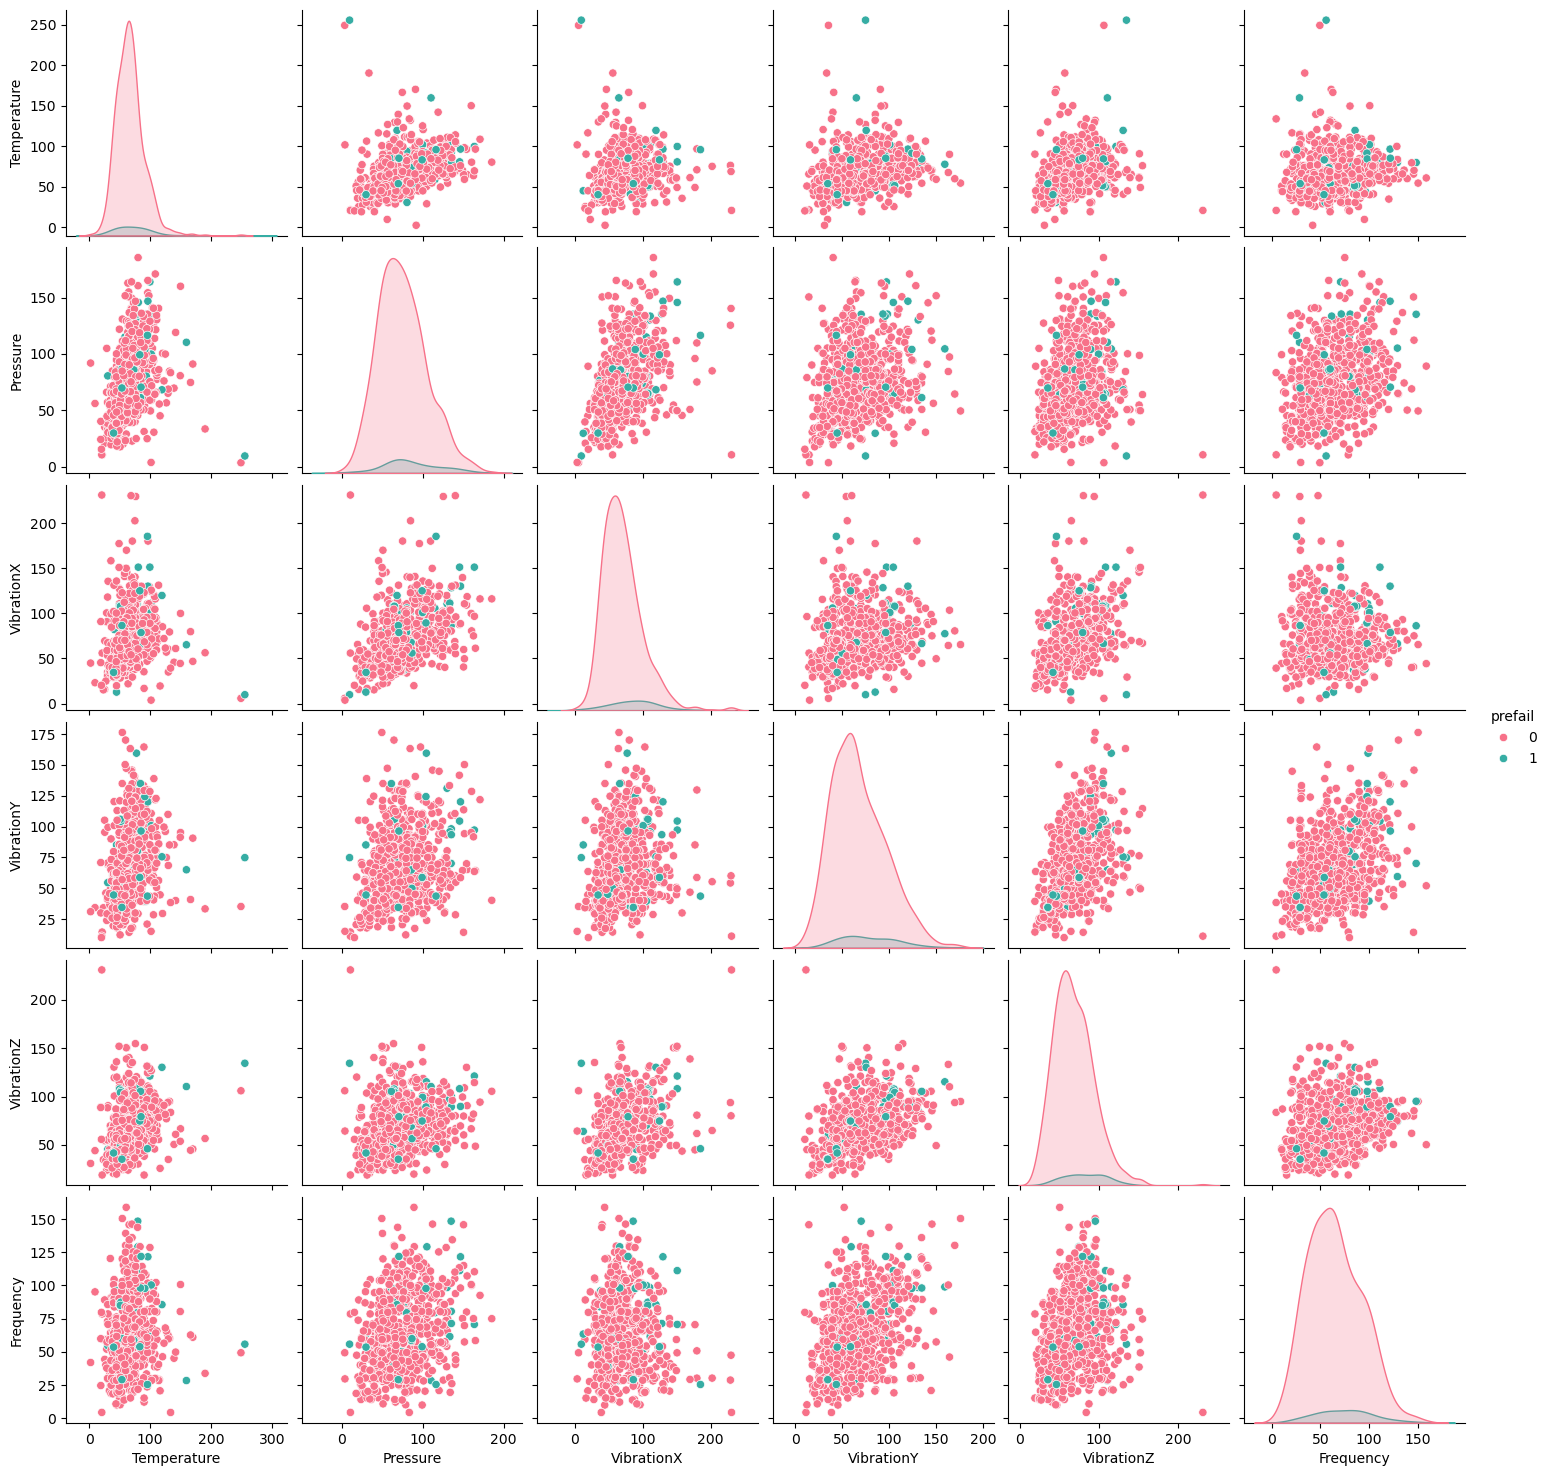

In [241]:
# Build the target (fail within 5 cycles) and drop in-failure rows, mirroring the model setup
plot_df = df.sort_values("Cycle").reset_index(drop=True).copy()
plot_df["prefail"] = create_target(plot_df, tau=5)   # 1 = within 5 cycles before onset
plot_df = plot_df[~plot_df["Fail"]].copy()            # drop actual failure rows

filtered_columns = ['Temperature', 'Pressure', 'VibrationX',
                    'VibrationY', 'VibrationZ', 'Frequency', 'prefail']
sns.pairplot(plot_df[filtered_columns], hue='prefail', palette='husl')

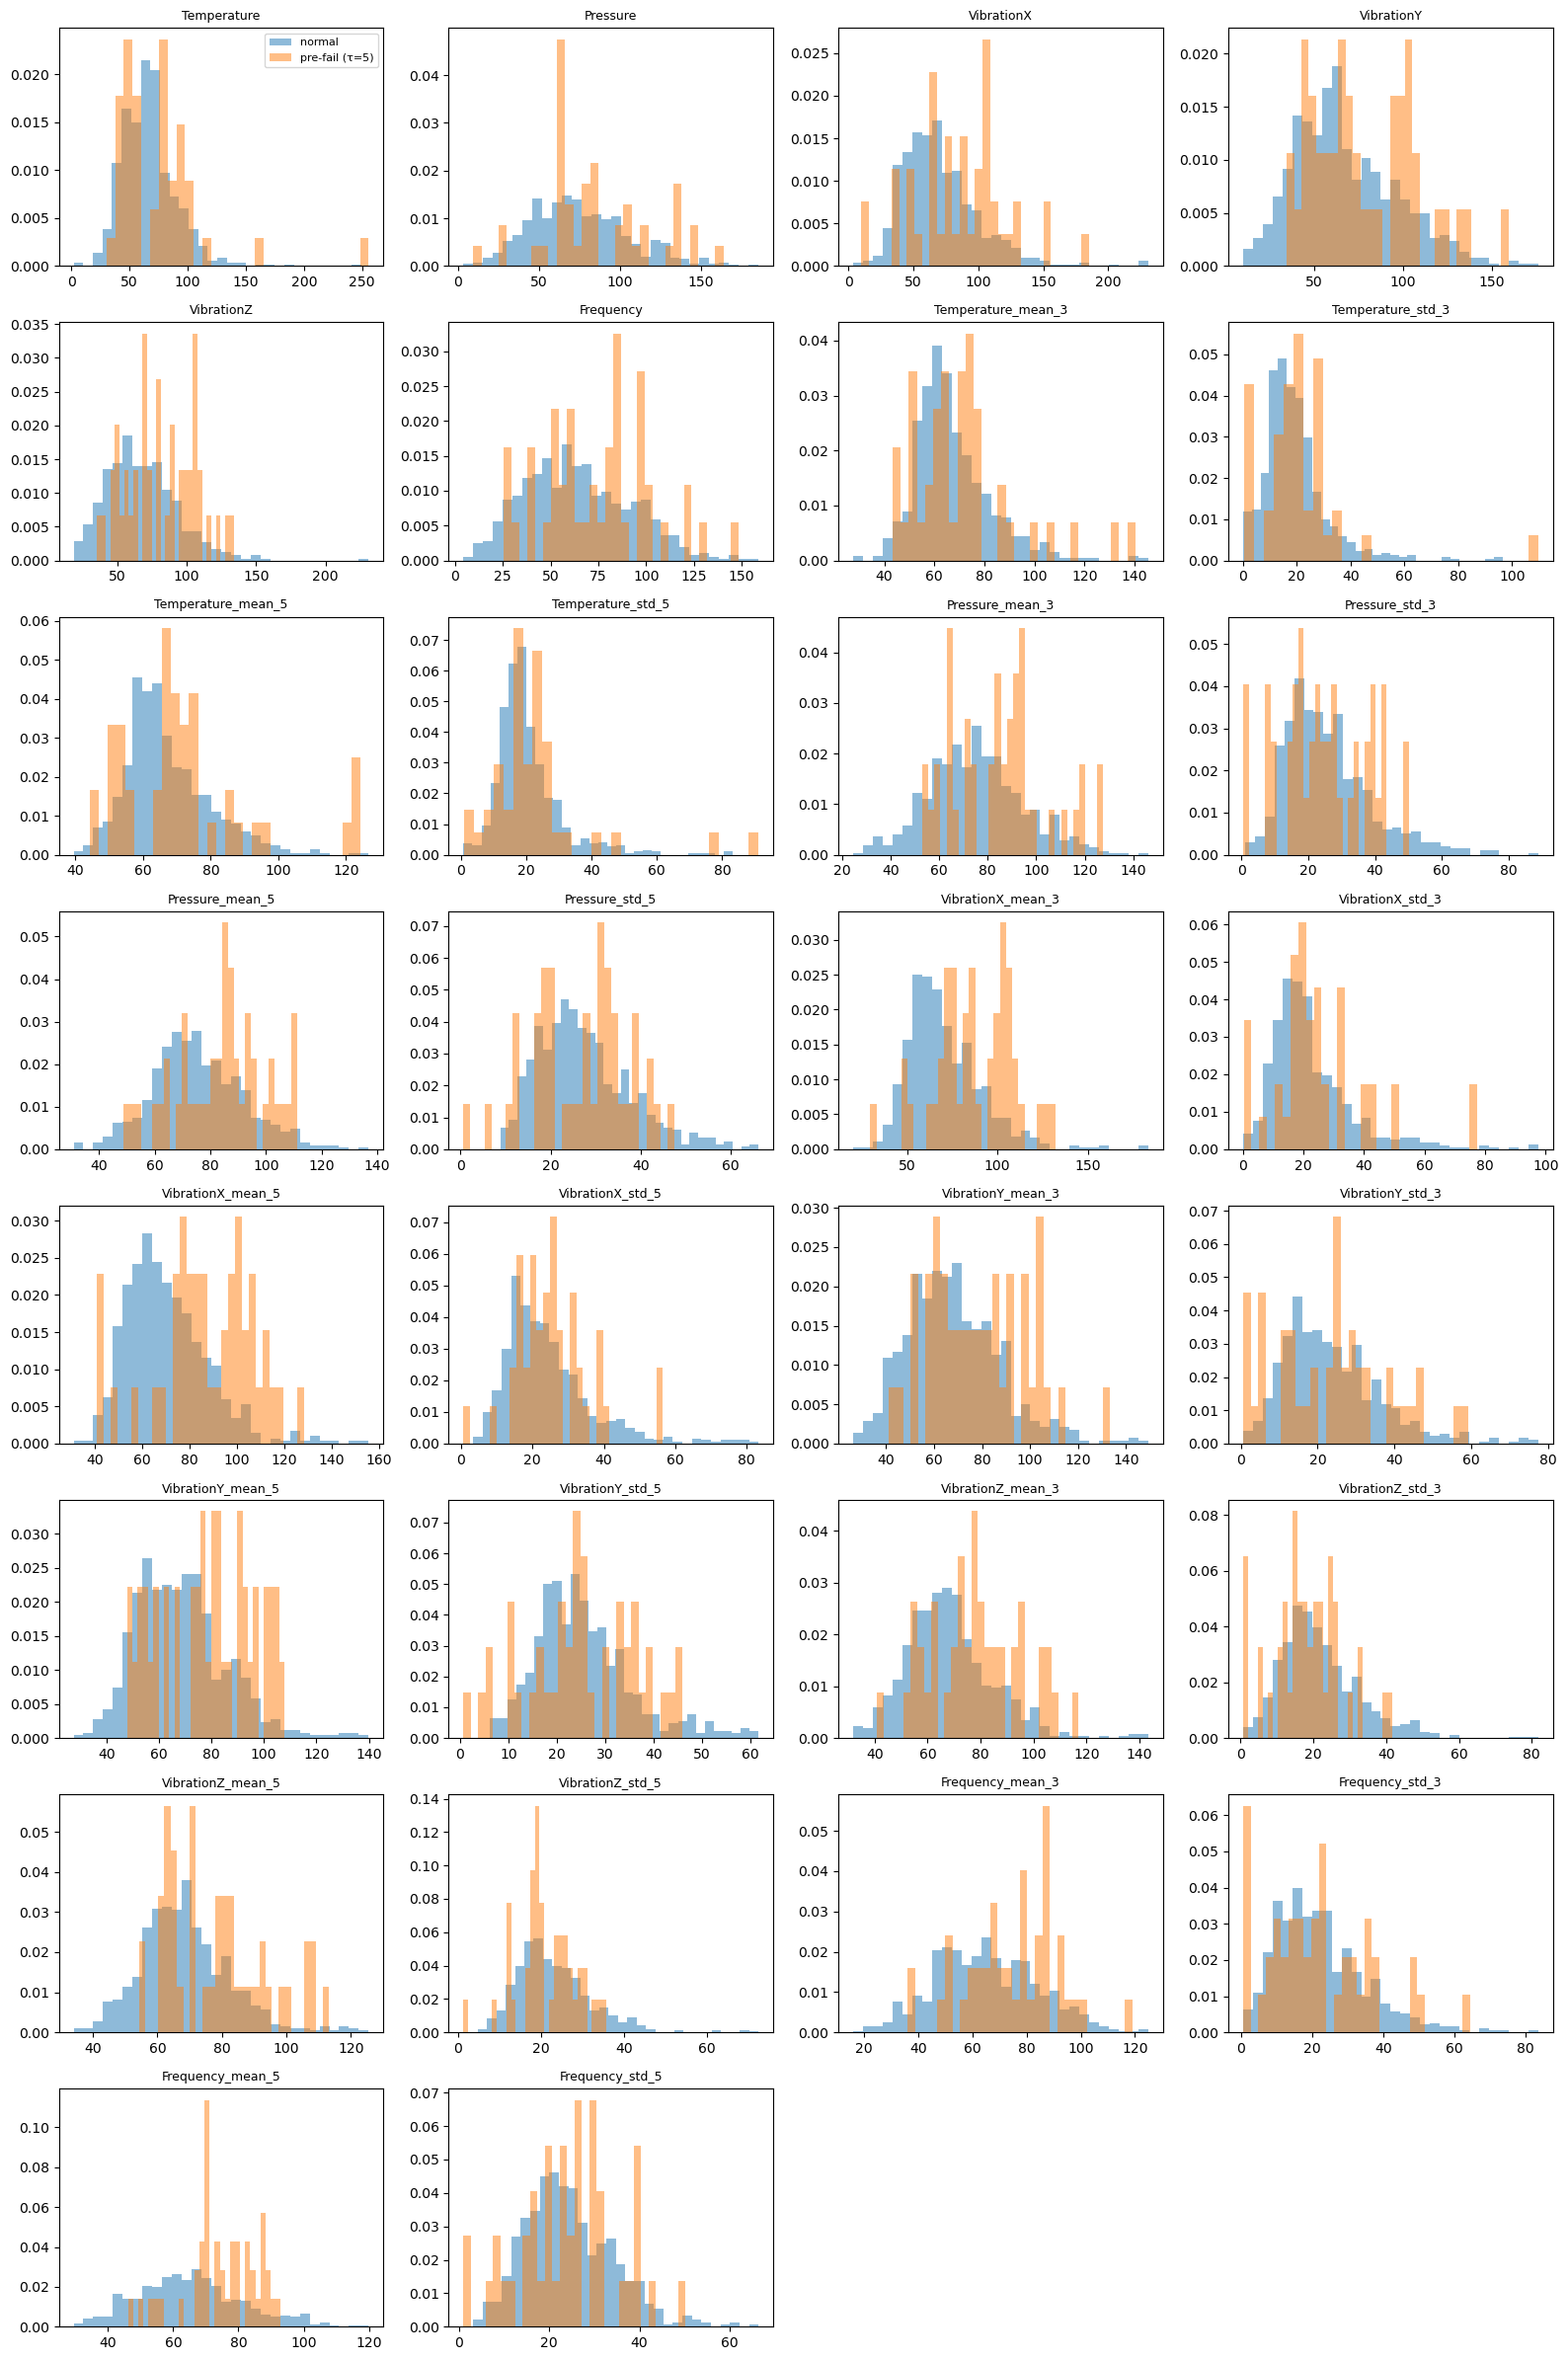

In [242]:
# Build target + features, drop in-failure rows (same setup as the model)
dist_df = df.sort_values("Cycle").reset_index(drop=True).copy()
dist_df["prefail"] = create_target(dist_df, tau=5)
dist_df = add_window_features(dist_df, sensors=sensors, windows=(3, 5))
dist_df = dist_df[~dist_df["Fail"]].copy()

window_cols = [f"{s}_{stat}_{w}" for s in sensors for w in (3, 5) for stat in ("mean", "std")]
all_features = sensors + window_cols

n = len(all_features)
ncols = 4
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))
for ax, feat in zip(axes.flat, all_features):
    # density per class so the rare pre-fail class isn't visually crushed
    ax.hist(dist_df.loc[dist_df["prefail"] == 0, feat], bins=30, alpha=0.5,
            density=True, label="normal")
    ax.hist(dist_df.loc[dist_df["prefail"] == 1, feat], bins=30, alpha=0.5,
            density=True, label="pre-fail (τ=5)")
    ax.set_title(feat, fontsize=9)
for ax in axes.flat[n:]:  # hide unused panels
    ax.axis("off")
axes.flat[0].legend(fontsize=8)
fig.tight_layout()
plt.show()